# Fake Restaurant Review Detection and XAI Analysis

## Phase 1. Data Acquisition and Preprocession

Before we build a robust review detection model, we need to get high quality data.

- Data sourcing: Gather restaurant review datasets (e.g., YelpZip, TripAdvisor datasets) that contain labeled fake/real reviews.
- Data cleaning: Remove duplicates, handle missing values, and clean the text (removing HTML tags, normalizing text).
- Exploratory Data Analysis (EDA): Analyze the distribution of fake vs. real reviews, review lengths, and common vocabularies.
- Tokenization: Prepare the text data for Transformer models using the appropriate tokenizer (e.g., Hugging Face's AutoTokenizer).

Import packages.

In [1]:
# Standard Library
from wordcloud import WordCloud
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    PreTrainedTokenizerBase,
    get_linear_schedule_with_warmup,
)
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from lime.lime_text import LimeTextExplainer
from captum.attr import LayerIntegratedGradients
from bs4 import BeautifulSoup
from IPython.display import HTML, display
import torch
import shap
from shap.maskers import Text as ShapTextMasker
import seaborn
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import gradio as gr
import datasets
import importlib
import pathlib
import re
import subprocess
import sys
import time
import unicodedata
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from typing import TypedDict, cast

Detect environment.

In [2]:
def detect_environment():
    if "google.colab" in sys.modules:
        return "Google Colab"
    # elif 'kaggle_web_client' in sys.modules:
    #     return "Kaggle"
    else:
        return "Local Jupyter"


running_env = detect_environment()
print(f"Current running environment: {running_env}")

Current running environment: Local Jupyter


In [3]:
# List of required packages
required_packages = {
    "datasets": "datasets",
    "gradio": "gradio",
    "matplotlib": "matplotlib",
    "nltk": "nltk",
    "numpy": "numpy",
    "pandas": "pandas",
    "seaborn": "seaborn",
    "shap": "shap",
    "torch": "torch",
    "bs4": "beautifulsoup4",
    "captum": "captum",
    "lime": "lime",
    "sklearn": "scikit-learn",
    "tqdm": "tqdm",
    "transformers": "transformers",
    "wordcloud": "wordcloud",
}


def install_if_missing(packages):
    for import_name, install_name in packages.items():
        try:
            importlib.import_module(import_name)
        except ImportError:
            if running_env == "Google Colab":
                print(
                    f"You are in Google Colab and missing {import_name}, installing {install_name}..."
                )
                subprocess.check_call(
                    [sys.executable, "-m", "pip", "install", install_name]
                )
            else:
                print(
                    f"[WARNING]: Missing '{install_name}',"
                    f"run `pip install {install_name}` manually."
                )


install_if_missing(required_packages)

try:
    from torch.amp import GradScaler as TorchGradScaler, autocast as torch_autocast


    def create_grad_scaler(enabled: bool):
        return TorchGradScaler("cuda", enabled=enabled)


    def amp_autocast(enabled: bool):
        return torch_autocast("cuda", enabled=enabled)

except ImportError:
    from torch.cuda.amp import GradScaler as TorchGradScaler, autocast as torch_autocast


    def create_grad_scaler(enabled: bool):
        return TorchGradScaler(enabled=enabled)


    def amp_autocast(enabled: bool):
        return torch_autocast(enabled=enabled)


def load_tokenizer(model_path) -> PreTrainedTokenizerBase:
    return cast(
        PreTrainedTokenizerBase, cast(object, AutoTokenizer.from_pretrained(model_path))
    )

### Phase 1 - Part 1. Data Sourcing

In [4]:
# Phase 1 - Part 1. Data Sourcing

# Create data directory
DATA_DIR = ""
MODEL_DIR = ""
YELP_ZIP_PATH = ""
YELP_CSV_PATH = ""

if running_env == "Google Colab":
    DATA_DIR = pathlib.Path("/content/drive/MyDrive/Guided_Study/data")
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    MODEL_DIR = pathlib.Path("/content/drive/MyDrive/Guided_Study/models")

    YELP_ZIP_PATH = DATA_DIR / "YelpZip.zip"
    YELP_CSV_PATH = DATA_DIR / "yelp_reviews.csv"
else:
    DATA_DIR = pathlib.Path("./data")
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    MODEL_DIR = pathlib.Path("./models")

    YELP_ZIP_PATH = DATA_DIR / "YelpZip.zip"
    YELP_CSV_PATH = DATA_DIR / "yelp_reviews.csv"


def load_from_huggingface() -> pd.DataFrame:
    print("Loading Yelp dataset from Hugging Face...")

    # Load the official Yelp Review Full dataset from Hugging Face
    # Dataset: https://huggingface.co/datasets/Yelp/yelp_review_full
    # Labels: 0-4 (star ratings); we binarize: <=2 stars → fake/negative (1), >=4 stars → real/positive (0)
    dataset = datasets.load_dataset(
        "Yelp/yelp_review_full", cache_dir=str(DATA_DIR / "hf_cache")
    )

    # Use the train split; sample 20,000 rows to keep it manageable
    df_train = pd.DataFrame(dataset["train"]).sample(n=20000, random_state=42)
    df_test = pd.DataFrame(dataset["test"])

    df = pd.concat([df_train, df_test], ignore_index=True)

    # Rename columns to standard names
    df.rename(columns={"text": "text", "label": "stars"}, inplace=True)

    # Binarize: treat 1–2 stars reviews as "fake/suspicious" (1), 4–5 stars as "real/genuine" (0)
    # Drop 3-star (neutral) reviews
    # drop 3-star (HF labels are 0-indexed: 0=1★ … 4=5★)
    df = df[df["stars"] != 2].copy()
    # 0★ or 1★ → fake(1), 3★–4★ → real(0)
    df["label"] = (df["stars"] <= 1).astype(int)

    df = df[["text", "label"]].reset_index(drop=True)
    df.to_csv(YELP_CSV_PATH, index=False)
    print(f"Dataset saved to {YELP_CSV_PATH} ({len(df)} records)")
    return df


# Load dataset
if YELP_CSV_PATH.exists():
    df_raw = cast(pd.DataFrame, pd.read_csv(str(YELP_CSV_PATH)))  # type: ignore[call-overload]
    print(f"Loaded existing dataset with {len(df_raw)} records.")
else:
    df_raw = load_from_huggingface()

print("Columns:", df_raw.columns.tolist())
print(f"Label distribution:\n{df_raw['label'].value_counts()}")
print(df_raw.head())

Loaded existing dataset with 55961 records.
Columns: ['text', 'label']
Label distribution:
label
1    27993
0    27968
Name: count, dtype: int64
                                                text  label
0  First of all i'm not a big fan of buffet, i tr...      1
1  Thanks Yelp. I was looking for the words to de...      1
2  I want to give a 2 stars because the service s...      1
3  Two stars for the sandwiches, negative three s...      1
4  I take my kids here at least two times a week....      0


### Phase 1 - Part 2. Data Cleaning

In [5]:
# Phase 1 - Part 2. Data Cleaning

# --- Standardize column names ---
# Adjust the mapping below to match your actual column names
# COLUMN_MAP = {
#     # "original_col": "standard_col"
#     # Example for YelpZip:
#     # "reviewContent": "review_text",
#     # "label": "label"   # 1 = fake, 0 = real
# }
#
# df = df_raw.rename(columns=COLUMN_MAP).copy()
df: pd.DataFrame = df_raw

# Ensure required columns exist; edit names to match your dataset
TEXT_COL = "text"  # column containing review text
LABEL_COL = "label"  # column containing fake(1) / real(0) label

# Verify columns
assert TEXT_COL in df.columns, (
    f"Column '{TEXT_COL}' not found. Available: {df.columns.tolist()}"
)
assert LABEL_COL in df.columns, (
    f"Column '{LABEL_COL}' not found. Available: {df.columns.tolist()}"
)

# Remove duplicates
before = len(df)
df.drop_duplicates(subset=[TEXT_COL], inplace=True)
print(f"Removed {before - len(df)} duplicate rows. Remaining: {len(df)}")

# Handle missing values
df.dropna(subset=[TEXT_COL, LABEL_COL], inplace=True)
print(f"After dropping nulls: {len(df)} rows")


# Text cleaning function
def clean_text(text: str) -> str:
    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()
    # Normalize unicode characters (e.g., accented chars)
    text = unicodedata.normalize("NFKD", text)
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    # Remove special characters and digits (keep letters and spaces)
    text = re.sub(r"[^a-z\s]", " ", text)
    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["clean_text"] = df[TEXT_COL].astype(str).apply(clean_text)

# Normalize labels to int (0 = real, 1 = fake)
df[LABEL_COL] = df[LABEL_COL].astype(int)

# Save cleaned data
CLEANED_PATH = DATA_DIR / "cleaned_reviews.csv"
df.to_csv(CLEANED_PATH, index=False)
print(f"Cleaned dataset saved to {CLEANED_PATH}")
print(df[["clean_text", LABEL_COL]].head())

Removed 0 duplicate rows. Remaining: 55961
After dropping nulls: 55961 rows
Cleaned dataset saved to data/cleaned_reviews.csv
                                          clean_text  label
0  first of all i m not a big fan of buffet i tri...      1
1  thanks yelp i was looking for the words to des...      1
2  i want to give a stars because the service sta...      1
3  two stars for the sandwiches negative three st...      1
4  i take my kids here at least two times a week ...      0


### Phase 1 - Part 3. Stop Words Removal

In [6]:
# Phase 1 - Part 3. Stop Word Removal

# Download required NLTK resources
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

# --- Load English stop words ---
STOP_WORDS = set(nltk.corpus.stopwords.words("english"))

# Optional: keep negation words (they carry sentiment/deception signals)
KEEP_WORDS = {
    "no",
    "not",
    "nor",
    "never",
    "neither",
    "none",
    "nobody",
    "nothing",
    "nowhere",
}
STOP_WORDS -= KEEP_WORDS

print(f"Total stop words: {len(STOP_WORDS)} (kept {len(KEEP_WORDS)} negation words)")


# Stop word removal function
def remove_stopwords(text: str) -> str:
    tokens = nltk.tokenize.word_tokenize(text)
    filtered = [word for word in tokens if word not in STOP_WORDS]
    return " ".join(filtered)


# Apply to cleaned text
before_avg_len = df["clean_text"].apply(lambda x: len(x.split())).mean()

df["clean_text"] = df["clean_text"].apply(remove_stopwords)

after_avg_len = df["clean_text"].apply(lambda x: len(x.split())).mean()

print(f"Average word count before stop word removal: {before_avg_len:.1f}")
print(f"Average word count after  stop word removal: {after_avg_len:.1f}")
print(f"Reduction: {(1 - after_avg_len / before_avg_len) * 100:.1f}%")

# Update the saved cleaned CSV
df.to_csv(CLEANED_PATH, index=False)
print(f"\nUpdated cleaned dataset saved to {CLEANED_PATH}")
print(df[["clean_text", LABEL_COL]].head())

Total stop words: 195 (kept 9 negation words)
Average word count before stop word removal: 137.3
Average word count after  stop word removal: 69.7
Reduction: 49.2%

Updated cleaned dataset saved to data/cleaned_reviews.csv
                                          clean_text  label
0  first not big fan buffet tried got credit stay...      1
1  thanks yelp looking words describe place meh s...      1
2  want give stars service staff friendly good we...      1
3  two stars sandwiches negative three stars neve...      1
4  take kids least two times week staff sweet top...      0


### Phase 1 Part 4. Exploratory Data Analysis (EDA)

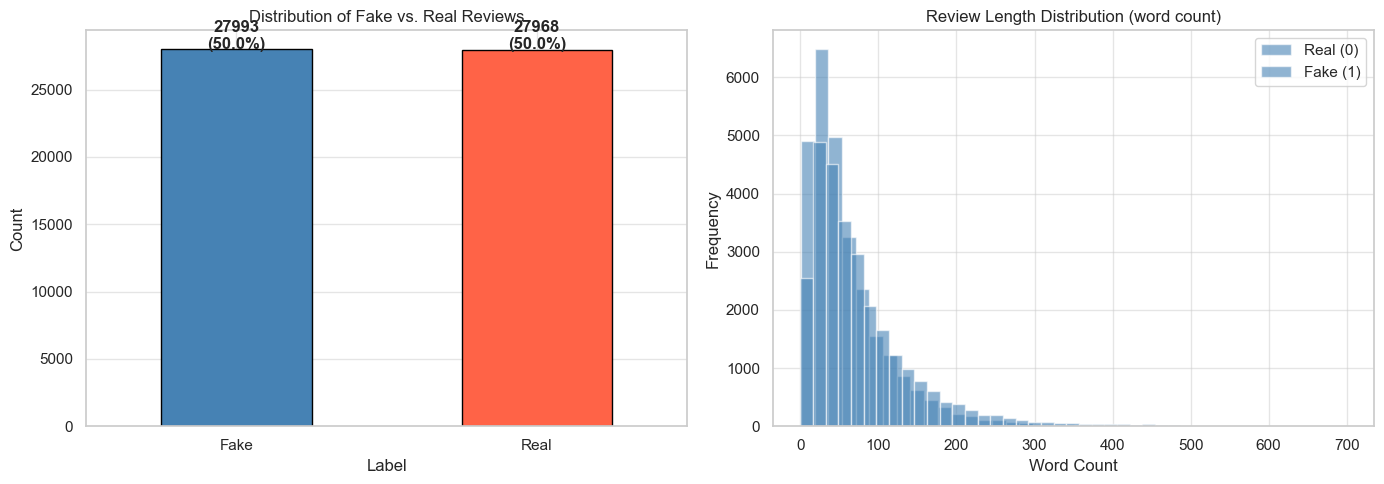


Review Length Statistics by Label:
         count       mean        std  min   25%   50%    75%    max
label                                                              
Real   27968.0  61.538544  57.414374  1.0  24.0  44.0   80.0  700.0
Fake   27993.0  77.905405  69.314317  0.0  31.0  57.0  102.0  649.0


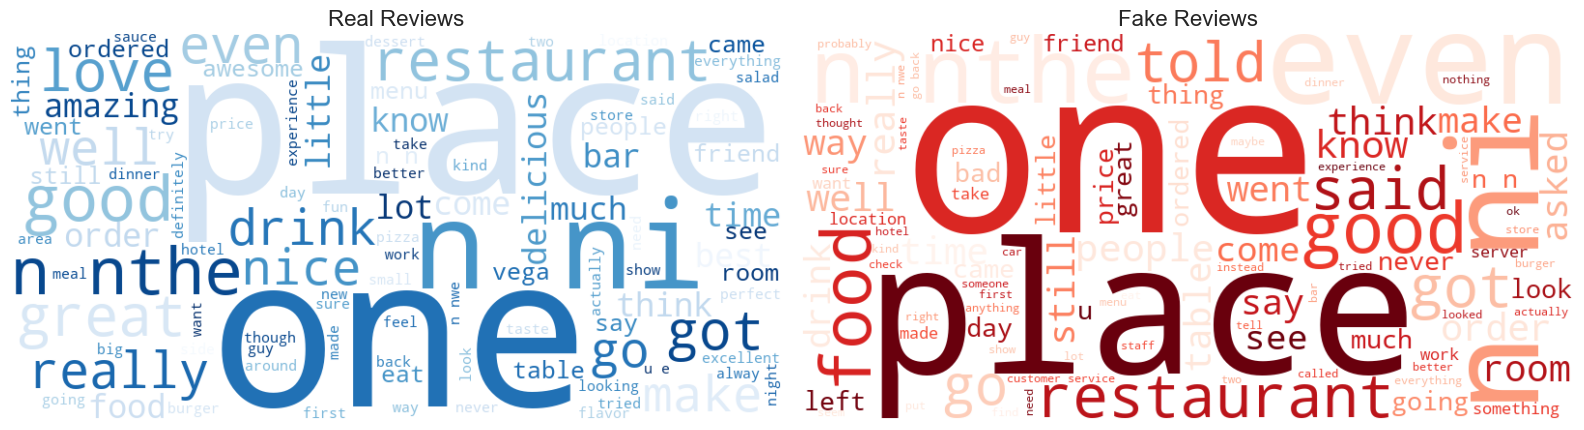

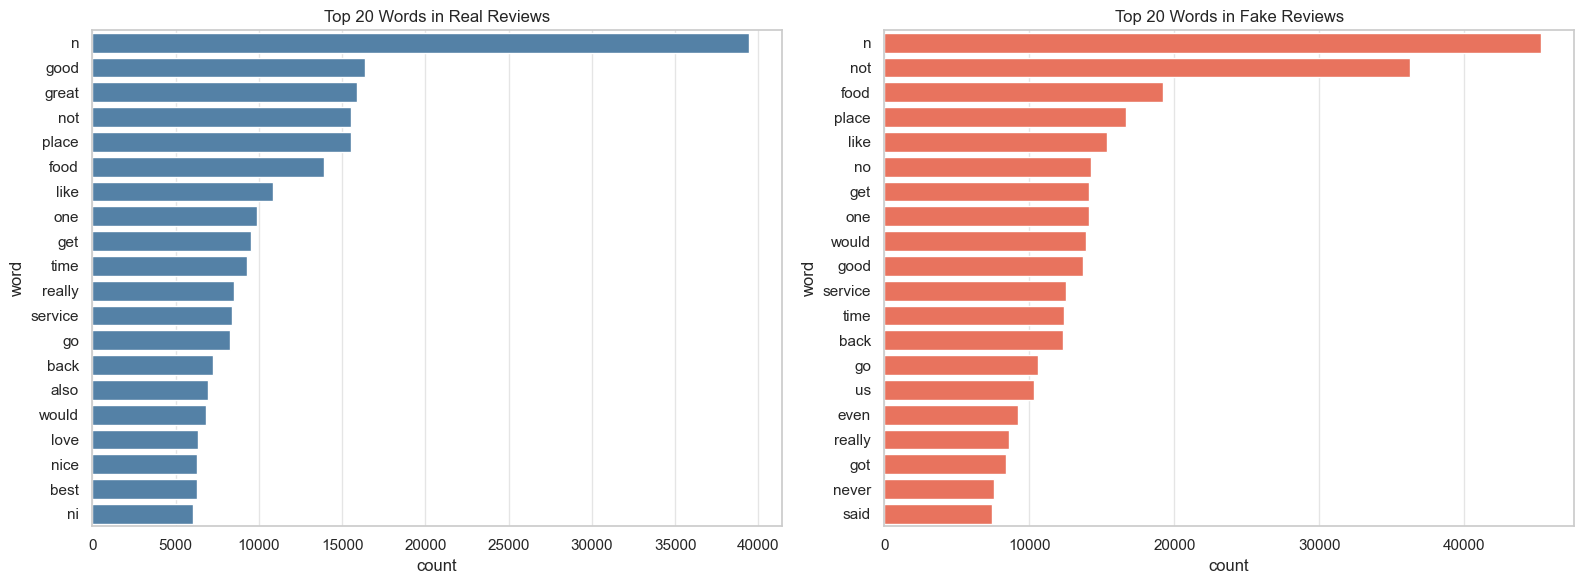


EDA complete. Plots saved to ./data/


In [7]:
# Phase 1 - Part 4: Exploratory Data Analysis (EDA)

seaborn.set_theme(style="whitegrid")

# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = df[LABEL_COL].value_counts().rename({0: "Real", 1: "Fake"})
label_counts.plot(
    kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="black"
)
axes[0].set_title("Distribution of Fake vs. Real Reviews")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(label_counts):
    axes[0].text(
        i, v + 10, f"{v}\n({v / len(df) * 100:.1f}%)", ha="center", fontweight="bold"
    )

# Review length distribution
df["review_length"] = df["clean_text"].apply(lambda x: len(x.split()))
df.groupby(LABEL_COL)["review_length"].plot(
    kind="hist",
    ax=axes[1],
    bins=40,
    alpha=0.6,
    legend=True,
    color=["steelblue", "tomato"],
)
axes[1].set_title("Review Length Distribution (word count)")
axes[1].set_xlabel("Word Count")
axes[1].legend(["Real (0)", "Fake (1)"])
plt.tight_layout()
plt.savefig(DATA_DIR / "eda_overview.png", dpi=300)
plt.show()
plt.close(fig)

# Descriptive statistics of review length
print("\nReview Length Statistics by Label:")
print(
    df.groupby(LABEL_COL)["review_length"]
    .describe()
    .rename(index={0: "Real", 1: "Fake"})
)

# Word clouds
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for label, title, ax in zip([0, 1], ["Real Reviews", "Fake Reviews"], axes):
    corpus = " ".join(df[df[LABEL_COL] == label]["clean_text"])
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=100,
        colormap="Blues" if label == 0 else "Reds",
    ).generate(corpus)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=16)
    ax.axis("off")
plt.tight_layout()
plt.savefig(DATA_DIR / "wordclouds.png", dpi=300)
plt.show()
plt.close(fig)

# Top 20 most common words per class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for label, title, ax, color in zip(
        [0, 1], ["Real", "Fake"], axes, ["steelblue", "tomato"]
):
    words = " ".join(df[df[LABEL_COL] == label]["clean_text"]).split()
    top_words = pd.DataFrame(Counter(words).most_common(20), columns=["word", "count"])
    seaborn.barplot(data=top_words, x="count", y="word", ax=ax, color=color)
    ax.set_title(f"Top 20 Words in {title} Reviews")
plt.tight_layout()
plt.savefig(DATA_DIR / "top_words.png", dpi=300)
plt.show()
plt.close(fig)

print("\nEDA complete. Plots saved to ./data/")

### Phase 1 - Part 5. Tokenization

In [8]:
# Phase 1 - Part 5. Tokenization

# Configuration
MODEL_NAME = "roberta-base"  # swap to "bert-base-uncased" if preferred
MAX_LENGTH = 256
BATCH_SIZE = 16
RANDOM_SEED = 42

# Load tokenizer
print(f"Loading tokenizer for model: {MODEL_NAME}")
tokenizer = load_tokenizer(MODEL_NAME)

# Train / Validation / Test split (70 / 15 / 15)
X = df["clean_text"].tolist()
y = df[LABEL_COL].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


# PyTorch Dataset
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx],
        }


# Build datasets and DataLoaders
train_dataset = ReviewDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset = ReviewDataset(X_val, y_val, tokenizer, MAX_LENGTH)
test_dataset = ReviewDataset(X_test, y_test, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Inspect a sample batch
sample_batch = next(iter(train_loader))
print("\nSample batch keys:", sample_batch.keys())
print("input_ids shape:      ", sample_batch["input_ids"].shape)
print("attention_mask shape: ", sample_batch["attention_mask"].shape)
print("labels shape:         ", sample_batch["labels"].shape)

# Decode a sample to verify tokenization
sample_idx = 0
decoded = tokenizer.decode(
    sample_batch["input_ids"][sample_idx], skip_special_tokens=True
)
print(
    f"\nDecoded sample (label={sample_batch['labels'][sample_idx].item()}):\n{decoded[:300]}..."
)

# Save split indices for reproducibility
split_df = pd.DataFrame(
    {
        "text": X_train + X_val + X_test,
        "label": y_train + y_val + y_test,
        "split": (
                ["train"] * len(X_train) + ["val"] * len(X_val) + ["test"] * len(X_test)
        ),
    }
)
split_df.to_csv(DATA_DIR / "data_splits.csv", index=False)
print(f"\nData splits saved to {DATA_DIR / 'data_splits.csv'}")
print("\n====[Phase 1 COMPLETE]====")

Loading tokenizer for model: roberta-base
Train: 39172 | Val: 8394 | Test: 8395

Sample batch keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
input_ids shape:       torch.Size([16, 256])
attention_mask shape:  torch.Size([16, 256])
labels shape:          torch.Size([16])

Decoded sample (label=0):
wonderful surprise stumbled upon stopped whim garth brooks show not realizing awesome place seated patio overlooking lake wall water immediately team servers went work lighting candle removing extra place settings assisting wife napkin literally five different people offering us outstanding service ...

Data splits saved to data/data_splits.csv

====[Phase 1 COMPLETE]====


## Phase 2. Model Development

This phase focus on developing the core classifier tailored for the restaurant domain.

- Baseline Models: Implement Heuristic/rule-based methods and traditional machine learning methods. This provides a benchmark.
- Transformer Implementation: Integrate State-of-the-Art (SOTA) Transformer-based language models (like BERT or RoBERTa). Fine-tune them specifically on your restaurant review datasets to capture subtle semantic cues of deception.
- Performance Evaluation: Evaluate your models using standard metrics: accuracy, precision, recall, and F1-score.

### Phase 2 - Part 1. Baseline Models

In [9]:
# Phase 2 - Part 1. Baseline Models


# Helper function
def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n{'=' * 50}")
    print(f"  {name}")
    print(f"{'=' * 50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=["Real (0)", "Fake (1)"],
            zero_division=0,
        )
    )
    return {"name": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


# Rule-based Heuristic Baseline
PROMO_WORDS = {
    "best",
    "amazing",
    "perfect",
    "fantastic",
    "incredible",
    "awesome",
    "wonderful",
    "excellent",
    "outstanding",
    "superb",
}


def heuristic_predict(texts, threshold=3):
    """Flag a review as fake if it contains >= threshold promotional words."""
    preds = []
    for text in texts:
        tokens = set(text.lower().split())
        preds.append(1 if len(tokens & PROMO_WORDS) >= threshold else 0)
    return preds


heuristic_preds = heuristic_predict(X_test)
results = [evaluate("Heuristic (Rule-Based)", y_test, heuristic_preds)]

# TF-IDF + Logistic Regression
lr_pipeline = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True),
        ),
        ("clf", LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED)),
    ]
)
lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
results.append(evaluate("TF-IDF + Logistic Regression", y_test, lr_preds))

# TF-IDF + Naïve Bayes
nb_pipeline = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True),
        ),
        ("clf", MultinomialNB()),
    ]
)
nb_pipeline.fit(X_train, y_train)
nb_preds = nb_pipeline.predict(X_test)
results.append(evaluate("TF-IDF + Naïve Bayes", y_test, nb_preds))

# TF-IDF + Linear SVM
svm_pipeline = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(max_features=50_000, ngram_range=(1, 2), sublinear_tf=True),
        ),
        ("clf", LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED)),
    ]
)
svm_pipeline.fit(X_train, y_train)
svm_preds = svm_pipeline.predict(X_test)
results.append(evaluate("TF-IDF + Linear SVM", y_test, svm_preds))

# Summary
baseline_df = pd.DataFrame(results).set_index("name")
print("\n\nBaseline Summary:")
print(baseline_df.to_string())


  Heuristic (Rule-Based)
  Accuracy : 0.4829
  Precision: 0.0617
  Recall   : 0.0024
  F1-Score : 0.0046
              precision    recall  f1-score   support

    Real (0)       0.49      0.96      0.65      4196
    Fake (1)       0.06      0.00      0.00      4199

    accuracy                           0.48      8395
   macro avg       0.28      0.48      0.33      8395
weighted avg       0.28      0.48      0.33      8395


  TF-IDF + Logistic Regression
  Accuracy : 0.9266
  Precision: 0.9258
  Recall   : 0.9276
  F1-Score : 0.9267
              precision    recall  f1-score   support

    Real (0)       0.93      0.93      0.93      4196
    Fake (1)       0.93      0.93      0.93      4199

    accuracy                           0.93      8395
   macro avg       0.93      0.93      0.93      8395
weighted avg       0.93      0.93      0.93      8395


  TF-IDF + Naïve Bayes
  Accuracy : 0.9048
  Precision: 0.9042
  Recall   : 0.9057
  F1-Score : 0.9049
              precision 

### Phase 2 - Part 2. Transformer Fine-Tuning (RoBERTa)

In [10]:
# Phase 2 - Part 2. Transformer Fine-Tuning (RoBERTa)

# Device setup
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [11]:
# Hyper-parameters
NUM_EPOCHS = 10
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
MODEL_SAVE_PATH = MODEL_DIR / "roberta_fake_review"
MODEL_CONFIG_PATH = MODEL_SAVE_PATH / "config.json"
MODEL_WEIGHTS_PATH = MODEL_SAVE_PATH / "model.safetensors"

# Reuse a saved fine-tuned checkpoint when it exists so the notebook can
# launch the dashboard without retraining every time.
USE_SAVED_MODEL = MODEL_CONFIG_PATH.exists() and (
        MODEL_WEIGHTS_PATH.exists() or (MODEL_SAVE_PATH / "pytorch_model.bin").exists()
)
print(f"Saved fine-tuned model available: {USE_SAVED_MODEL}")

if USE_SAVED_MODEL:
    print(f"\nLoading previously fine-tuned model from {MODEL_SAVE_PATH}...")
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_PATH)
    tokenizer = load_tokenizer(MODEL_SAVE_PATH)
    model.to(DEVICE)
    history = {"train_loss": [], "val_loss": [], "val_f1": []}
else:
    # Load pre-trained model and fine-tune it only when no checkpoint exists.
    print(f"\nLoading {MODEL_NAME} for sequence classification...")
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    model.to(DEVICE)

    # Optimizer & Scheduler
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    total_steps = len(train_loader) * NUM_EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )
    use_amp = DEVICE.type == "cuda"
    scaler = create_grad_scaler(enabled=use_amp)

    # Training loop
    history = {"train_loss": [], "val_loss": [], "val_f1": []}
    best_val_f1 = 0.0


    def run_epoch(loader, training=True):
        model.train() if training else model.eval()
        total_loss, all_preds, all_labels = 0.0, [], []

        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            for batch in tqdm(
                    loader, desc="Train" if training else "Val ", leave=False
            ):
                input_ids = batch["input_ids"].to(DEVICE)
                attention_mask = batch["attention_mask"].to(DEVICE)
                labels = batch["labels"].to(DEVICE)

                with amp_autocast(enabled=use_amp):
                    outputs = model(
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels,
                    )
                    loss = outputs.loss

                if training:
                    optimizer.zero_grad()
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    scheduler.step()

                total_loss += loss.item()
                preds = outputs.logits.argmax(dim=-1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(labels.cpu().numpy())

        avg_loss = total_loss / len(loader)
        f1 = f1_score(all_labels, all_preds, zero_division=0)
        return avg_loss, f1, all_preds, all_labels


    print("\nStarting fine-tuning...\n")

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_f1, _, _ = run_epoch(train_loader, training=True)
        val_loss, val_f1, _, _ = run_epoch(val_loader, training=False)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)

        print(
            f"Epoch {epoch}/{NUM_EPOCHS}  |  "
            f"Train Loss: {train_loss:.4f}  |  "
            f"Val Loss: {val_loss:.4f}  |  "
            f"Val F1: {val_f1:.4f}"
        )

        # Save best model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            model.save_pretrained(MODEL_SAVE_PATH)
            tokenizer.save_pretrained(MODEL_SAVE_PATH)
            print(f"  ✓ Best model saved  (Val F1={best_val_f1:.4f})")

    print("\nFine-tuning complete.")

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_range = range(1, NUM_EPOCHS + 1)

    axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs_range, history["val_loss"], marker="o", label="Val Loss")
    axes[0].set_title("Loss Curves")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(
        epochs_range, history["val_f1"], marker="o", color="green", label="Val F1"
    )
    axes[1].set_title("Validation F1")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1 Score")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(DATA_DIR / "training_curves.png", dpi=300)
    plt.show()
    plt.close(fig)

Saved fine-tuned model available: True

Loading previously fine-tuned model from models/roberta_fake_review...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

### Phase 2 - Part 3. Performance Evaluation

Loading best saved model for evaluation...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Testing:   0%|          | 0/525 [00:00<?, ?it/s]


  roberta-base (Fine-tuned)
  Accuracy : 0.9494
  Precision: 0.9491
  Recall   : 0.9497
  F1-Score : 0.9494
              precision    recall  f1-score   support

    Real (0)       0.95      0.95      0.95      4196
    Fake (1)       0.95      0.95      0.95      4199

    accuracy                           0.95      8395
   macro avg       0.95      0.95      0.95      8395
weighted avg       0.95      0.95      0.95      8395



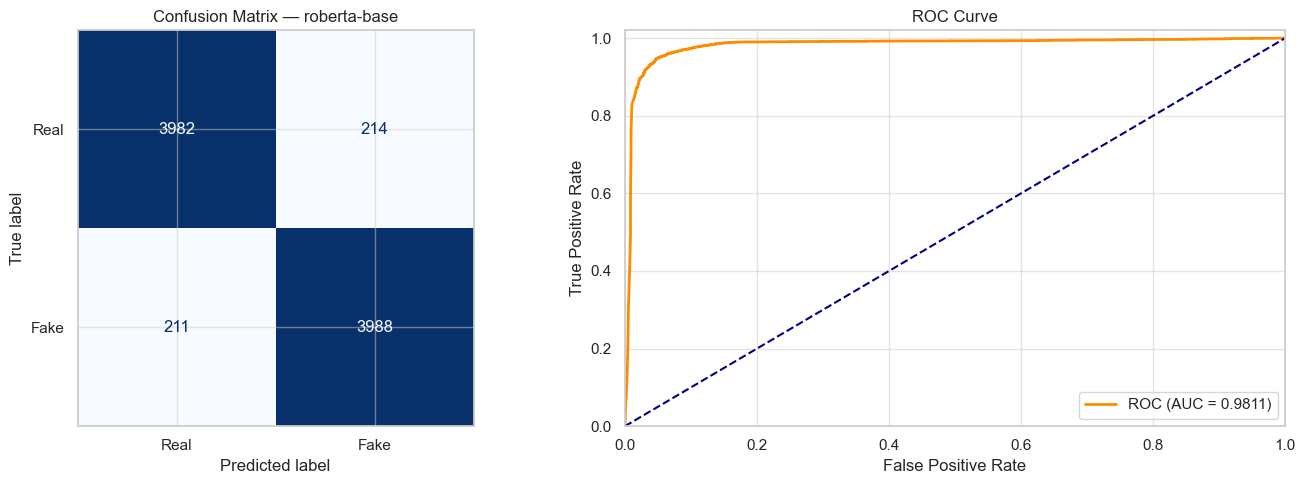


  PHASE 2 — FINAL MODEL COMPARISON
                              accuracy  precision  recall      f1
name                                                             
Heuristic (Rule-Based)          0.4829     0.0617  0.0024  0.0046
TF-IDF + Logistic Regression    0.9266     0.9258  0.9276  0.9267
TF-IDF + Naïve Bayes            0.9048     0.9042  0.9057  0.9049
TF-IDF + Linear SVM             0.9307     0.9283  0.9336  0.9309
roberta-base (Fine-tuned)       0.9494     0.9491  0.9497  0.9494

✓ Best model by F1: [roberta-base (Fine-tuned)]  F1=0.9494

Results saved to data/phase2_results.csv

====[Phase 2 COMPLETE]====


In [12]:
# Phase 2 - Part 3. Performance Evaluation

# Load the best saved model for evaluation
print("Loading best saved model for evaluation...")
best_model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_PATH)
best_model.to(DEVICE)
best_model.eval()

# Run inference on test set
all_preds: list[int] = []
all_labels: list[int] = []
all_probs: list[float] = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=-1)[:, 1]  # prob of Fake
        preds = outputs.logits.argmax(dim=-1)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())

# Metrics
transformer_result = evaluate(f"{MODEL_NAME} (Fine-tuned)", all_labels, all_preds)
results.append(transformer_result)

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix — {MODEL_NAME}")

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", linestyle="--")
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(DATA_DIR / "evaluation_plots.png", dpi=300)
plt.show()
plt.close(fig)

# Final Comparison Table
all_results_df = pd.DataFrame(results).set_index("name")
print("\n" + "=" * 65)
print("  PHASE 2 — FINAL MODEL COMPARISON")
print("=" * 65)
print(all_results_df.round(4).to_string())

# Highlight best model
best_model_name = all_results_df["f1"].idxmax()
print(
    f"\n✓ Best model by F1: [{best_model_name}]  "
    f"F1={all_results_df.loc[best_model_name, 'f1']:.4f}"
)

all_results_df.to_csv(DATA_DIR / "phase2_results.csv")
print(f"\nResults saved to {DATA_DIR / 'phase2_results.csv'}")
print("\n====[Phase 2 COMPLETE]====")

## Phase 3. Explainable AI Integration

This part we bridge the gap between the black box mechanism and human understanding.

- Apply LIME: Use Local Interpretable Model-agnostic Explanations (LIME) to understand local predictions and extract feature importance scores.
- Apply SHAP: Integrate SHAP (Shapley Additive exPlanations) for both global and local interpretability.
- Reason Code Generation: Map the mathematical outputs of SHAP/LIME into your proposed "Reason Codes" (e.g., translating a high SHAP value for promotional words into a flag for "excessive promotional language")

### Phase 3 - Part 1. LIME

Loading best model for XAI analysis...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


────────────────────────────────────────────────────────────
Case : True Positive (Correctly detected Fake)
True : Fake  |  Pred: Fake
Text : alright tried place based reviews clearly needs reviews place terrible thing good people right good ready quick ordered beef szechuan like no idea make threw bunch vegetables together duck sauce calle...

────────────────────────────────────────────────────────────
Case : True Negative (Correctly detected Real)
True : Real  |  Pred: Real
Text : review one item vanilla swirl let call traveling vanilla swirl thing pauses drop breath everything could asked soft flavorful puts plain croissants shame purchased two filling barely able finish one n...

────────────────────────────────────────────────────────────
Case : False Positive (Real misclassified Fake)
True : Real  |  Pred: Fake
Text : tldr better wine friendly attendants good crowd casinos wide progressive game nonsmoking room available n nstation casino bingo better although game never reaches

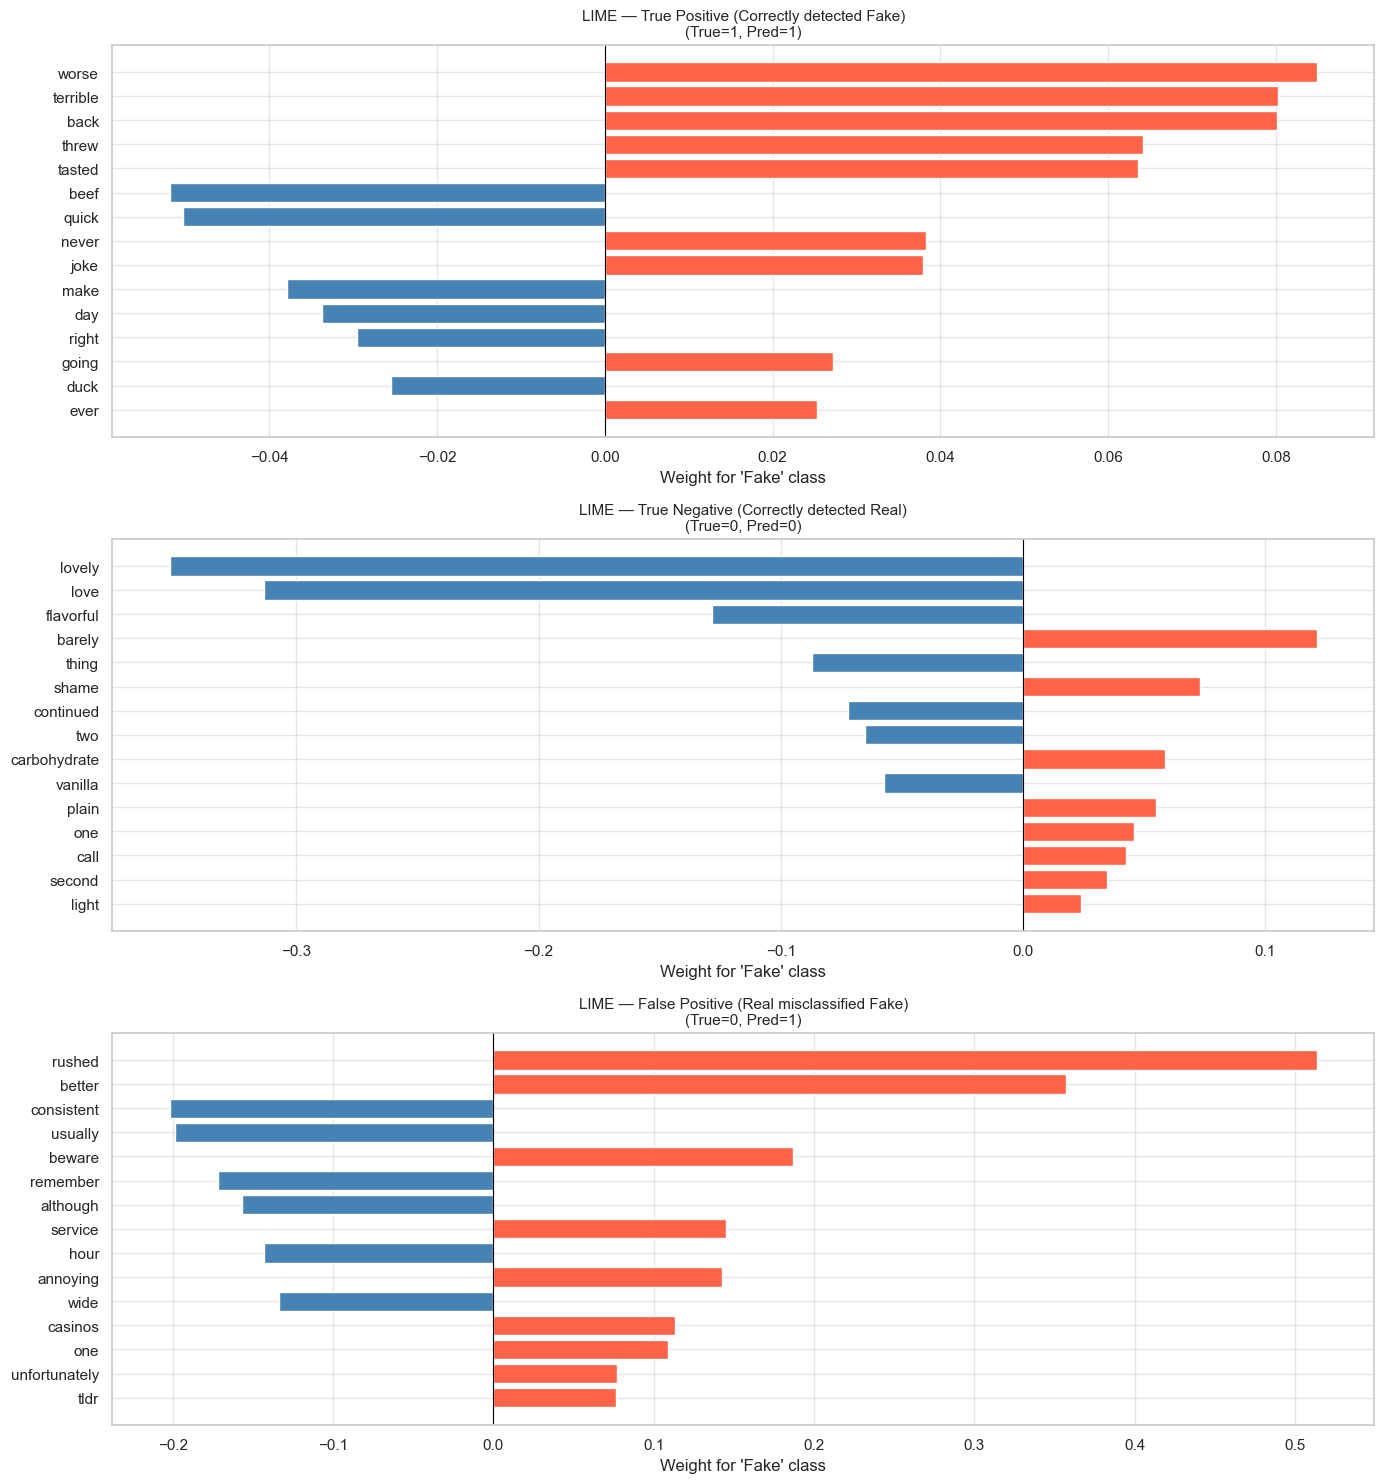


HTML visualization for: True Positive (Correctly detected Fake)



====[LIME analysis COMPLETE]====


In [13]:
# Phase 3 - Part 1. LIME (Local Interpretable Model-agnostic Explanations)

# Load best model (reuse if already in memory)
print("Loading best model for XAI analysis...")
xai_tokenizer = load_tokenizer(MODEL_SAVE_PATH)
xai_model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_PATH)
xai_model.to(DEVICE)
xai_model.eval()


# Prediction function for LIME
def lime_predict_proba(texts: list[str]) -> np.ndarray:
    """
    LIME calls this with a list of perturbed text strings.
    Returns an (N, 2) probability array: [P(Real), P(Fake)].
    """
    all_probs = []
    batch_size = 16
    for i in range(0, len(texts), batch_size):
        batch = texts[i: i + batch_size]
        encoding = xai_tokenizer(
            batch,
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        encoding = {k: v.to(DEVICE) for k, v in encoding.items()}
        with torch.no_grad():
            logits = xai_model(**encoding).logits
        # Cast to float32 before softmax to avoid MPS float64 error
        probs = torch.softmax(logits.float(), dim=-1).cpu().to(torch.float32).numpy()
        all_probs.append(probs)
    return np.vstack(all_probs).astype(np.float32)


# LIME Explainer Setup
lime_explainer = LimeTextExplainer(
    class_names=["Real (0)", "Fake (1)"],
    split_expression=r"\W+",  # word-level splitting
    random_state=RANDOM_SEED,
)

# Select representative samples for explanation
# Pick 3 test samples: 1 true-fake (TP), 1 true-real (TN), 1 false-positive (FP)
all_preds_arr = np.array(all_preds)
all_labels_arr = np.array(all_labels)

tp_idx = np.where((all_labels_arr == 1) & (all_preds_arr == 1))[0]
tn_idx = np.where((all_labels_arr == 0) & (all_preds_arr == 0))[0]
fp_idx = np.where((all_labels_arr == 0) & (all_preds_arr == 1))[0]

sample_indices = {
    "True Positive (Correctly detected Fake)": tp_idx[0] if len(tp_idx) > 0 else 0,
    "True Negative (Correctly detected Real)": tn_idx[0] if len(tn_idx) > 0 else 1,
    "False Positive (Real misclassified Fake)": fp_idx[0] if len(fp_idx) > 0 else 2,
}

lime_explanations = {}
fig, axes = plt.subplots(len(sample_indices), 1, figsize=(14, 5 * len(sample_indices)))

for (case_name, idx), ax in zip(sample_indices.items(), axes):
    text = X_test[idx]
    true_l = y_test[idx]
    pred_l = int(all_preds_arr[idx])

    print(f"\n{'─' * 60}")
    print(f"Case : {case_name}")
    print(
        f"True : {'Fake' if true_l == 1 else 'Real'}  |  Pred: {'Fake' if pred_l == 1 else 'Real'}"
    )
    print(f"Text : {text[:200]}...")

    exp = lime_explainer.explain_instance(
        text,
        lime_predict_proba,
        num_features=15,
        num_samples=500,
        labels=[1],  # explain Fake class
    )
    lime_explanations[case_name] = exp

    # Bar chart of top features
    feature_weights = exp.as_list(label=1)
    words, weights = zip(*feature_weights)
    colors = ["tomato" if w > 0 else "steelblue" for w in weights]
    ax.barh(words, weights, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"LIME — {case_name}\n(True={true_l}, Pred={pred_l})", fontsize=11)
    ax.set_xlabel("Weight for 'Fake' class")
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(DATA_DIR / "lime_explanations.png", dpi=300)
plt.show()
plt.close(fig)

# Display HTML visualization for the first sample
first_key = next(iter(lime_explanations))
print(f"\nHTML visualization for: {first_key}")
display(HTML(lime_explanations[first_key].as_html()))

print("\n====[LIME analysis COMPLETE]====")

### Phase 3 - Part 2. SHAP Analysis

SHAP is adopted here as the complementary explanation mechanism to LIME because it provides Shapley-consistent additive attributions that can be interpreted both locally and globally. In this implementation, the fine-tuned RoBERTa detector is reused from Part 1, and the same representative test cases selected for LIME are carried forward so that the two explanation methods remain directly comparable. A whitespace text masker is paired with SHAP's partition-based explainer, while `shap_predict_proba()` converts masked text perturbations into the class-probability format required by SHAP.

Running SHAP on 3 samples …


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  33%|███▎      | 1/3 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 3/3 [00:58<00:00, 14.33s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [01:25, 28.39s/it]                       

SHAP computation complete.
shap_lookup built with 3 entries.


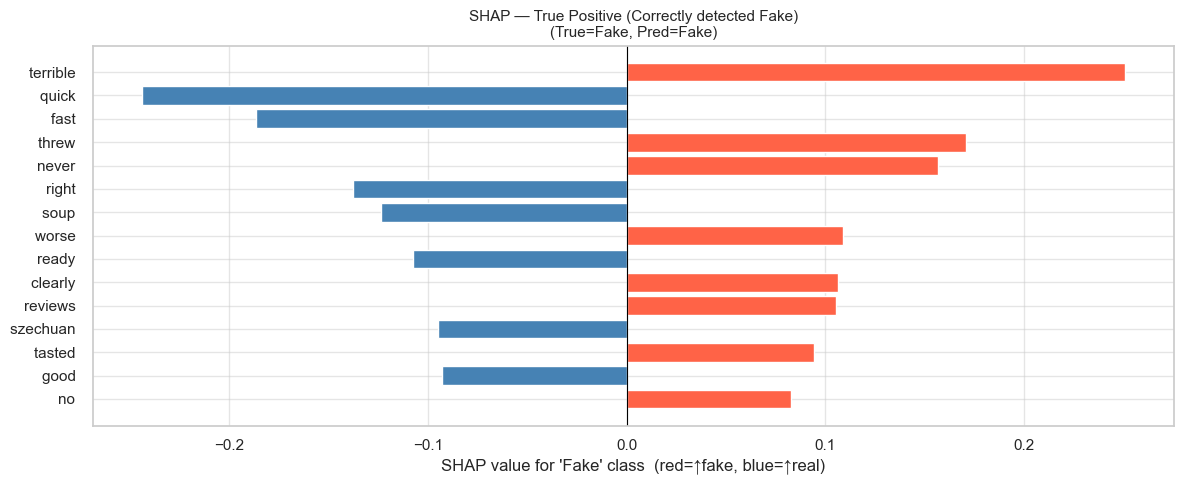

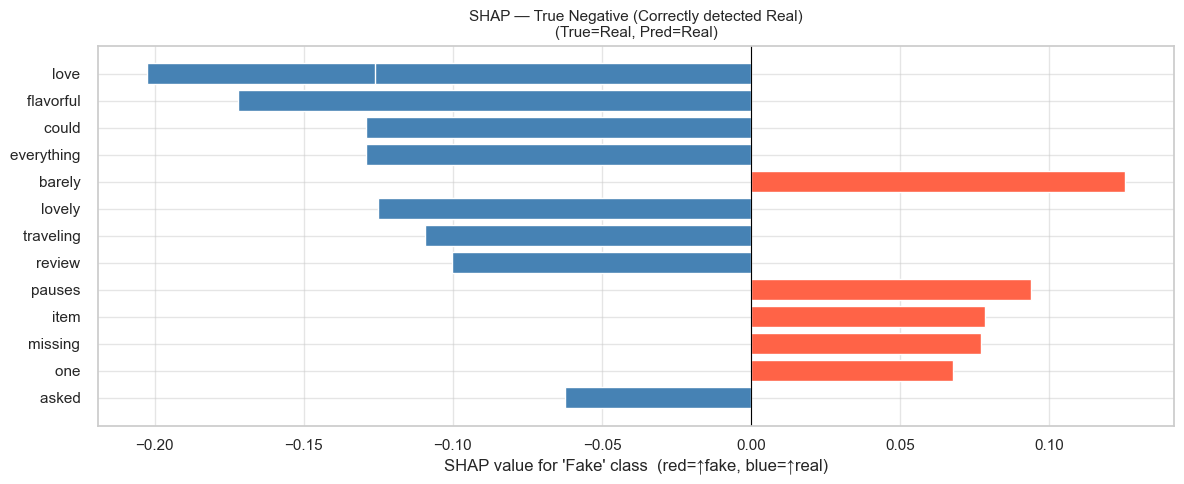

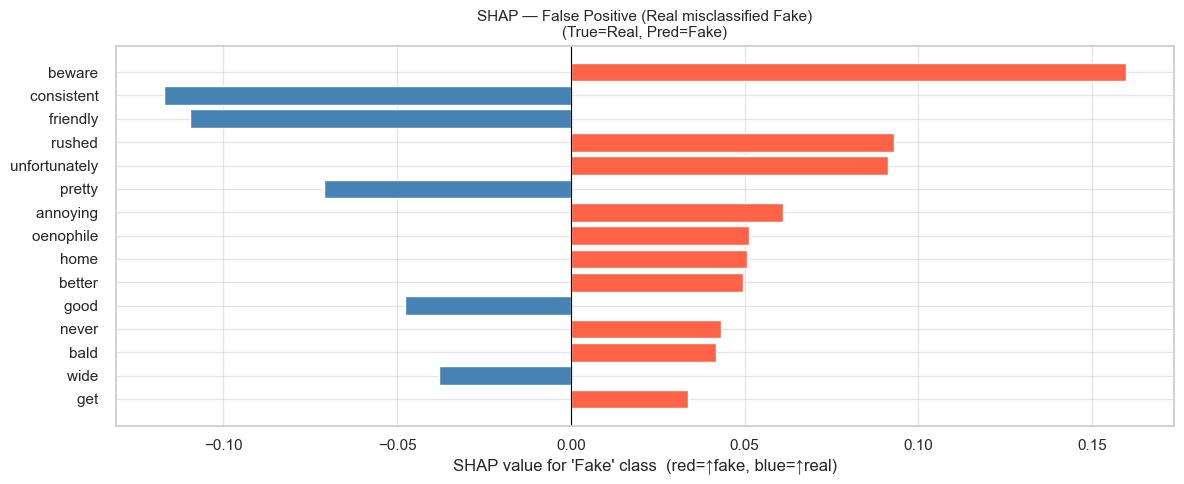

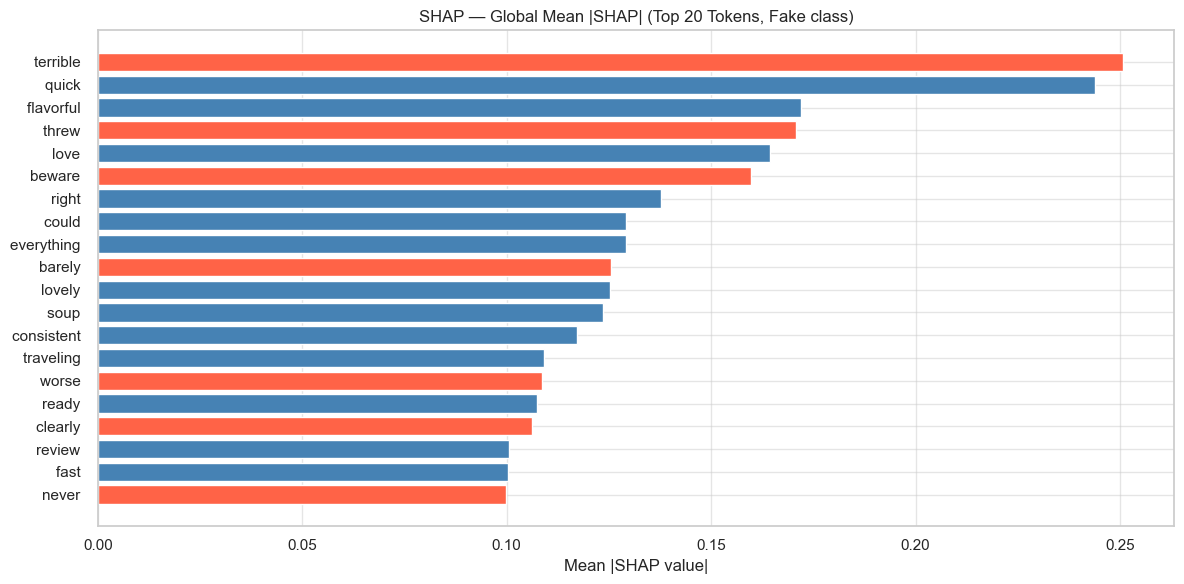


Global SHAP summary saved to data/shap_global_importance.csv

====[SHAP analysis COMPLETE]====


In [14]:
# Phase 3 - Part 2. SHAP Analysis


class ShapLookupEntry(TypedDict):
    feature_names: list[str]
    values: np.ndarray


# Uses SHAP's Partition explainer (recommended for Transformers).
# Produces:
#   shap_lookup : dict[text -> {"feature_names": list, "values": np.ndarray}]

# Reuse model already loaded in Part 1
# (xai_model, xai_tokenizer, DEVICE, MAX_LENGTH are already in memory)


# Prediction function for SHAP — must return numpy array
def shap_predict_proba(texts) -> np.ndarray:
    """
    SHAP calls this with a list/array of (possibly masked) text strings.
    Returns an (N, 2) array: [P(Real), P(Fake)].
    """
    # SHAP may pass numpy array; ensure it's a plain list of strings
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()
    if isinstance(texts, str):
        texts = [texts]
    texts = [str(t) if not isinstance(t, str) else t for t in texts]

    all_probs: list[np.ndarray] = []
    batch_size = 8
    for i in range(0, len(texts), batch_size):
        batch = texts[i: i + batch_size]
        encoding = xai_tokenizer(
            batch,
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        encoding = {k: v.to(DEVICE) for k, v in encoding.items()}
        with torch.no_grad():
            logits = xai_model(**encoding).logits
        probs = torch.softmax(logits.float(), dim=-1).cpu().to(torch.float32).numpy()
        all_probs.append(probs)
    return np.vstack(all_probs).astype(np.float64)


# Build SHAP Explainer using PartitionExplainer with word-level masker
masker = ShapTextMasker(tokenizer=r"\s+")
shap_explainer = shap.Explainer(
    shap_predict_proba,
    masker=masker,
    output_names=["Real (0)", "Fake (1)"],
    algorithm="partition",
)

# Select samples (reuse same indices from Part 1 LIME)
shap_sample_texts = [X_test[idx] for idx in sample_indices.values()]
shap_sample_labels = [y_test[idx] for idx in sample_indices.values()]
shap_sample_preds = [int(all_preds_arr[idx]) for idx in sample_indices.values()]
shap_sample_probs = [float(all_probs[idx]) for idx in sample_indices.values()]

print(f"Running SHAP on {len(shap_sample_texts)} samples …")
# Truncate long texts to speed up SHAP and avoid token explosion
MAX_WORDS_SHAP = 100
shap_texts_truncated = [" ".join(t.split()[:MAX_WORDS_SHAP]) for t in shap_sample_texts]
shap_values = shap_explainer(shap_texts_truncated)
print("SHAP computation complete.")

# Build shap_lookup: original_text → {feature_names, values} for Fake class
shap_lookup: dict[str, ShapLookupEntry] = {}
for i, text in enumerate(shap_sample_texts):
    sv = shap_values[i]
    feature_names = list(sv.data)  # use .data for the actual token strings

    # Handle shape: values may be (n_tokens, n_classes) or (n_tokens,)
    vals_raw = sv.values
    if vals_raw.ndim == 2:
        vals = vals_raw[:, 1].astype(np.float32)  # Fake class
    else:
        vals = vals_raw.astype(np.float32)

    shap_lookup[text] = {
        "feature_names": feature_names,
        "values": vals,
    }

print(f"shap_lookup built with {len(shap_lookup)} entries.")

# Visualisations — per-sample bar charts
for i, (case_name, idx) in enumerate(sample_indices.items()):
    text = shap_sample_texts[i]
    true_l = shap_sample_labels[i]
    pred_l = shap_sample_preds[i]

    feature_names = shap_lookup[text]["feature_names"]
    vals = shap_lookup[text]["values"]

    # Bar chart: top-15 tokens by |SHAP| for Fake class
    top_k = min(15, len(feature_names))
    top_idx = np.argsort(np.abs(vals))[::-1][:top_k]
    top_tokens = [feature_names[j] for j in top_idx]
    top_vals = vals[top_idx]
    colors = ["tomato" if v > 0 else "steelblue" for v in top_vals]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(top_tokens, top_vals, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(
        f"SHAP — {case_name}\n"
        f"(True={'Fake' if true_l == 1 else 'Real'}, "
        f"Pred={'Fake' if pred_l == 1 else 'Real'})",
        fontsize=11,
    )
    ax.set_xlabel("SHAP value for 'Fake' class  (red=↑fake, blue=↑real)")
    ax.invert_yaxis()
    plt.tight_layout()
    safe_name = case_name[:25].replace(" ", "_")
    plt.savefig(DATA_DIR / f"shap_{safe_name}.png", dpi=300)
    plt.show()
    plt.close(fig)

    # SHAP text plot (waterfall-style, Fake class)
    try:
        shap.plots.text(shap_values[i, :, 1])
    except Exception as e:
        print(f"  [shap.plots.text skipped: {e}]")

# Global: mean |SHAP| across all explained samples
all_tokens: list[str] = []
all_vals: list[float] = []
for entry in shap_lookup.values():
    all_tokens.extend(entry["feature_names"])
    all_vals.extend(entry["values"].tolist())

token_df = pd.DataFrame({"token": all_tokens, "shap": all_vals})
mean_df = (
    token_df.groupby("token")["shap"]
    .agg(mean_abs=lambda x: np.mean(np.abs(x)), mean_val="mean")
    .reset_index()
    .sort_values("mean_abs", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["tomato" if v > 0 else "steelblue" for v in mean_df["mean_val"]]
ax.barh(mean_df["token"], mean_df["mean_abs"], color=colors)
ax.set_title("SHAP — Global Mean |SHAP| (Top 20 Tokens, Fake class)")
ax.set_xlabel("Mean |SHAP value|")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(DATA_DIR / "shap_global_importance.png", dpi=300)
plt.show()
plt.close(fig)

mean_df.to_csv(DATA_DIR / "shap_global_importance.csv", index=False)
print(f"\nGlobal SHAP summary saved to {DATA_DIR / 'shap_global_importance.csv'}")
print("\n====[SHAP analysis COMPLETE]====")

### Phase 3 - Part 3. Integrated Gradients

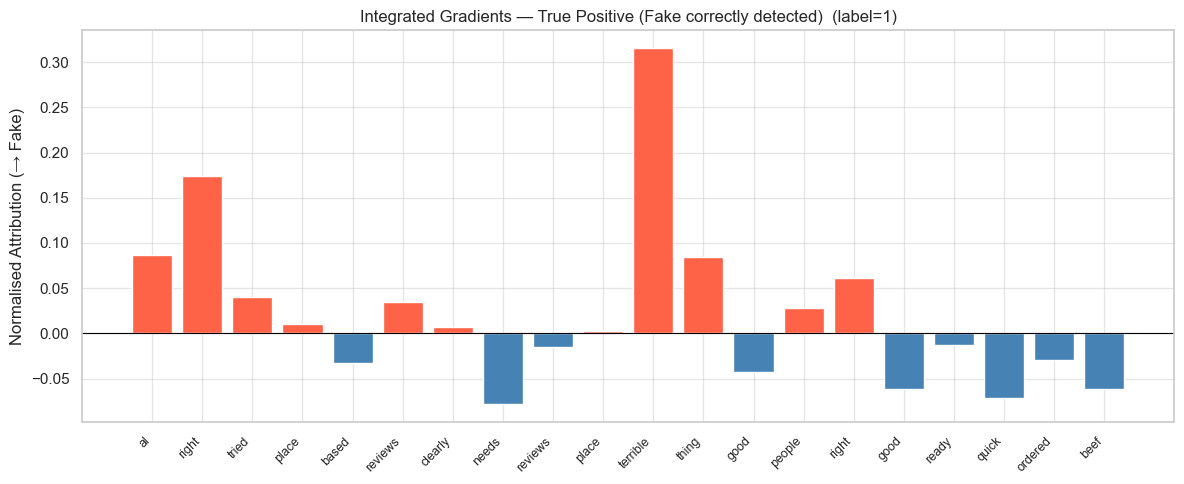

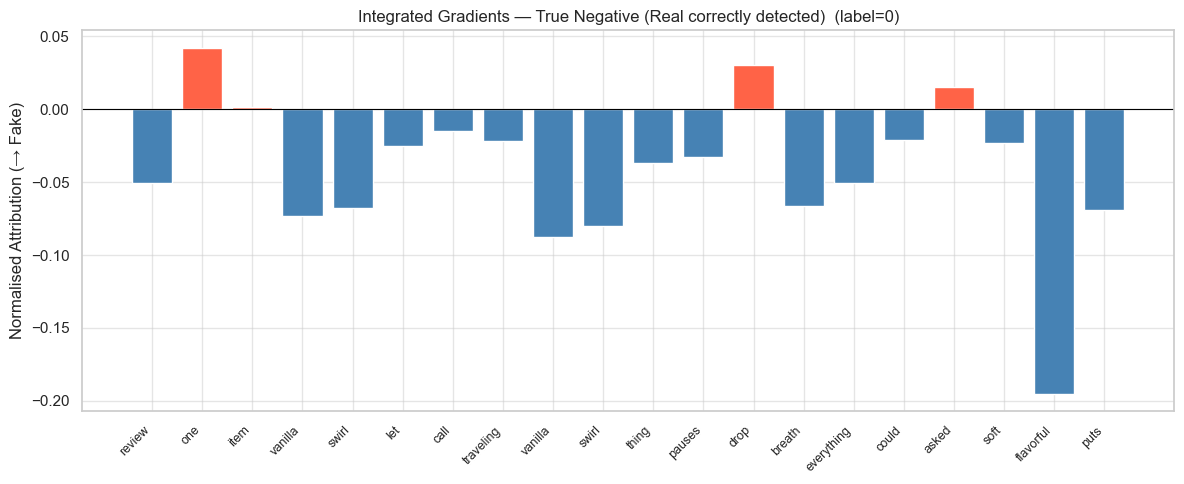


====[Integrated Gradients analysis COMPLETE]====


In [15]:
# Phase 3 - Part 3. Integrated Gradients (Transformer-native XAI)

# Complements LIME/SHAP with gradient-based attribution directly
# on the model's embedding layer — no sampling or approximation.

# Helper: token-level attribution


def get_ig_attributions(
        text: str, target_class: int = 1, n_steps: int = 50
) -> tuple[list[str], np.ndarray]:
    """
    Returns (tokens, attributions) for `text` w.r.t. `target_class`.
    Attributions are summed over the embedding dimension and L2-normalised.
    """
    xai_model.eval()
    enc = xai_tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    input_ids = enc["input_ids"].to(DEVICE)
    attention_mask = enc["attention_mask"].to(DEVICE)

    # Baseline: all [PAD] tokens
    baseline_ids = torch.zeros_like(input_ids)

    def forward_func(input_embeds, attention_mask):
        outputs = xai_model(inputs_embeds=input_embeds, attention_mask=attention_mask)
        return torch.softmax(outputs.logits, dim=-1)[:, target_class]

    embedding_layer = xai_model.roberta.embeddings  # adjust if using BERT
    lig = LayerIntegratedGradients(forward_func, embedding_layer)

    baseline_embeds = embedding_layer(baseline_ids)
    input_embeds = embedding_layer(input_ids)

    attributions, _ = lig.attribute(
        inputs=input_embeds,
        baselines=baseline_embeds,
        additional_forward_args=(attention_mask,),
        n_steps=n_steps,
        return_convergence_delta=True,
    )

    # Sum over embedding dim → (seq_len,)
    attr = attributions.squeeze(0).sum(dim=-1).detach().cpu().numpy()

    # Mask padding tokens
    mask = attention_mask.squeeze(0).cpu().numpy().astype(bool)
    tokens = xai_tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).cpu().numpy())
    tokens = [t for t, m in zip(tokens, mask) if m]
    attr = attr[mask]

    # L2 normalise
    norm = np.linalg.norm(attr)
    attr = attr / (norm + 1e-10)
    return tokens, attr


def render_ig_html(tokens: list[str], attrs: np.ndarray, title: str = "") -> str:
    """Render token-level IG attributions as coloured HTML."""
    norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=attrs.min(), vmax=attrs.max())
    cmap = plt.get_cmap("RdYlGn_r")  # red = fake-pushing, green = real-pushing
    parts = [f"<b>{title}</b><br><br>"]
    for tok, a in zip(tokens, attrs):
        rgba = cmap(norm(a))
        hex_c = mcolors.to_hex((float(rgba[0]), float(rgba[1]), float(rgba[2])))
        word = tok.replace("Ġ", " ").replace("▁", " ")
        parts.append(
            f'<span style="background:{hex_c};padding:2px 4px;'
            f'border-radius:3px;margin:1px;display:inline-block">{word}</span>'
        )
    return "".join(parts)


# Run IG on a few test examples
ig_sample_indices = {
    "True Positive (Fake correctly detected)": tp_idx[0] if len(tp_idx) else 0,
    "True Negative (Real correctly detected)": tn_idx[0] if len(tn_idx) else 1,
}

ig_results = {}
for case_name, idx in ig_sample_indices.items():
    text = X_test[idx]
    label = y_test[idx]
    tokens, attrs = get_ig_attributions(text, target_class=1)
    ig_results[case_name] = {
        "tokens": tokens,
        "attrs": attrs,
        "text": text,
        "label": label,
    }

    # Bar chart
    # Filter special tokens for display
    display_pairs = [
        (t.replace("Ġ", "").replace("▁", ""), a)
        for t, a in zip(tokens, attrs)
        if t not in ("<s>", "</s>", "<pad>")
    ][:20]
    d_tokens, d_attrs = zip(*display_pairs)
    colors = ["tomato" if a > 0 else "steelblue" for a in d_attrs]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(len(d_tokens)), d_attrs, color=colors)
    ax.set_xticks(range(len(d_tokens)))
    ax.set_xticklabels(d_tokens, rotation=45, ha="right", fontsize=9)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"Integrated Gradients — {case_name}  (label={label})")
    ax.set_ylabel("Normalised Attribution (→ Fake)")
    plt.tight_layout()
    plt.savefig(DATA_DIR / f"ig_{case_name[:20].replace(' ', '_')}.png", dpi=300)
    plt.show()
    plt.close(fig)

    # HTML token highlight
    html = render_ig_html(tokens, attrs, title=f"{case_name} | label={label}")
    display(HTML(html))

print("\n====[Integrated Gradients analysis COMPLETE]====")

### Phase 3 - Part 4. Reason Code Generation

  PHASE 3 — REASON CODE GENERATION

Reason code output saved to data/reason_codes_output.csv

── Bulk Reason Code generation on full test set ──

Reason Code frequency across all FAKE predictions:
 code                                       label  count
RC-01              Excessive Promotional Language     91
RC-02             Generic / Template-like Content    152
RC-03                  Extreme Sentiment Polarity   4200
RC-04 Suspicious Urgency / Action-Prompt Language     77


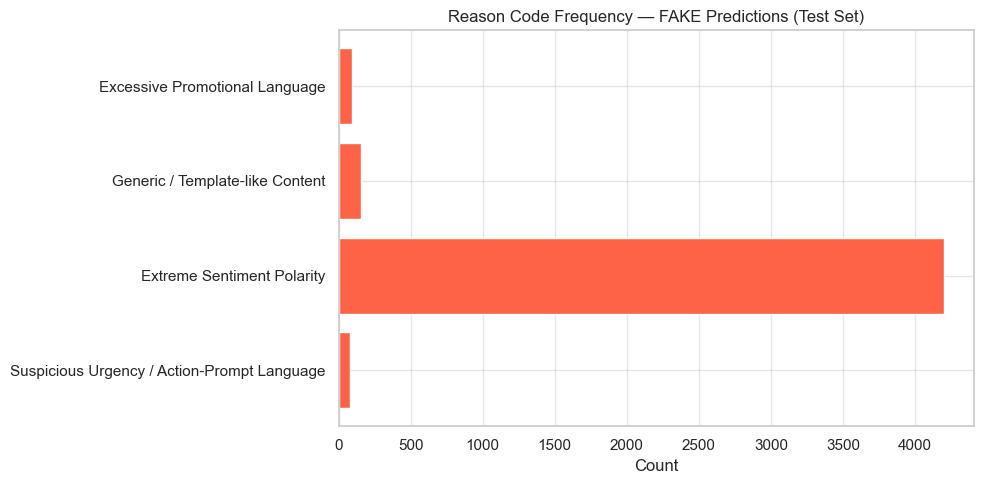


Frequency table saved to data/reason_code_frequency.csv

====[Phase 3 COMPLETE]====


In [16]:
# Phase 3 - Part 4. Reason Code Generation

# Maps SHAP/LIME/IG attributions → human-readable "Reason Codes"
# that explain *why* a review was flagged as fake.

# Reason Code Taxonomy
REASON_CODES: dict[str, dict] = {
    "RC-01": {
        "label": "Excessive Promotional Language",
        "description": "Review contains an unusually high density of superlative "
                       "or marketing-style words that inflate sentiment artificially.",
        "trigger_words": {
            "amazing",
            "incredible",
            "fantastic",
            "perfect",
            "best",
            "awesome",
            "outstanding",
            "phenomenal",
            "superb",
            "excellent",
            "wonderful",
            "brilliant",
            "magnificent",
            "unbelievable",
            "flawless",
        },
    },
    "RC-02": {
        "label": "Generic / Template-like Content",
        "description": "Review uses common phrases found across many fake reviews "
                       "and lacks specific, personal detail.",
        "trigger_words": {
            "highly recommend",
            "must try",
            "worth every penny",
            "five stars",
            "ten out of ten",
            "do not hesitate",
            "rush",
            "hurry",
            "everyone should",
            "trust me",
        },
    },
    "RC-03": {
        "label": "Extreme Sentiment Polarity",
        "description": "Review's predicted confidence is very high (>0.85), "
                       "indicating an atypically one-sided opinion.",
        "trigger_condition": "high_confidence",
    },
    "RC-04": {
        "label": "Suspicious Urgency / Action-Prompt Language",
        "description": "Review pushes the reader to take immediate action, "
                       "a pattern associated with incentivised/fake reviews.",
        "trigger_words": {
            "go now",
            "visit today",
            "book immediately",
            "hurry up",
            "limited time",
            "dont wait",
            "you wont regret",
            "call now",
            "order now",
            "grab",
        },
    },
    "RC-05": {
        "label": "High XAI Attribution to Non-Descriptive Tokens",
        "description": "SHAP/LIME/IG flags tokens that are not descriptive "
                       "of the actual experience, suggesting manufactured content.",
        "trigger_condition": "xai_non_descriptive",
    },
}

DESCRIPTIVE_TOKENS = {
    "food",
    "service",
    "staff",
    "price",
    "taste",
    "flavor",
    "portion",
    "menu",
    "table",
    "wait",
    "ambiance",
    "atmosphere",
    "location",
    "fresh",
    "cooked",
    "served",
    "ordered",
    "meal",
    "dish",
    "drink",
}


# Core Reason-Code Engine
@dataclass
class ReviewExplanation:
    text: str
    true_label: int
    predicted: int
    fake_prob: float
    reason_codes: list[str] = field(default_factory=list)
    evidence: dict[str, list] = field(default_factory=dict)
    summary: str = ""

    def __str__(self):
        sep = "─" * 60
        lines = [
            sep,
            f"Text     : {self.text[:200]}{'...' if len(self.text) > 200 else ''}",
            f"Predicted: {'⚠ FAKE' if self.predicted == 1 else '✓ REAL'} "
            f"(P(Fake)={self.fake_prob:.3f})  |  True: {'FAKE' if self.true_label == 1 else 'REAL'}",
        ]
        if self.reason_codes:
            lines.append("\nReason Codes:")
            for rc in self.reason_codes:
                meta = REASON_CODES[rc]
                lines.append(f"  [{rc}] {meta['label']}")
                lines.append(f"         {meta['description']}")
                if rc in self.evidence:
                    lines.append(f"         Evidence: {self.evidence[rc]}")
        else:
            lines.append("No strong fake-review signals detected.")
        lines.append(f"\nSummary : {self.summary}")
        lines.append(sep)
        return "\n".join(lines)


def generate_reason_codes(
        text: str,
        true_label: int,
        predicted: int,
        fake_prob: float,
        lime_exp=None,  # lime Explanation object (or None)
        shap_tokens: list[str] | None = None,
        shap_attrs: np.ndarray | None = None,
        ig_tokens: list[str] | None = None,
        ig_attrs: np.ndarray | None = None,
        shap_threshold: float = 0.05,
        ig_threshold: float = 0.10,
        confidence_threshold: float = 0.85,
) -> ReviewExplanation:
    reason_codes: list[str] = []
    evidence: dict[str, list] = {}
    lower_text = text.lower()

    # RC-01: Promotional language
    promo_hits = [
        w for w in REASON_CODES["RC-01"]["trigger_words"] if w in lower_text.split()
    ]
    if len(promo_hits) >= 2:
        reason_codes.append("RC-01")
        evidence["RC-01"] = promo_hits

    # RC-02: Template / generic phrases
    generic_hits = [
        p for p in REASON_CODES["RC-02"]["trigger_words"] if p in lower_text
    ]
    if generic_hits:
        reason_codes.append("RC-02")
        evidence["RC-02"] = generic_hits

    # RC-03: Extreme confidence
    if fake_prob >= confidence_threshold:
        reason_codes.append("RC-03")
        evidence["RC-03"] = [f"P(Fake)={fake_prob:.3f}"]

    # RC-04: Urgency language
    urgency_hits = [
        p for p in REASON_CODES["RC-04"]["trigger_words"] if p in lower_text
    ]
    if urgency_hits:
        reason_codes.append("RC-04")
        evidence["RC-04"] = urgency_hits

    # RC-05: XAI attribution to non-descriptive tokens
    flagged_non_descriptive: list[str] = []

    # From LIME
    if lime_exp is not None:
        lime_features = lime_exp.as_list(label=1)
        for word, weight in lime_features:
            clean = re.sub(r"[^a-z]", "", word.lower())
            if weight > 0.05 and clean and clean not in DESCRIPTIVE_TOKENS:
                flagged_non_descriptive.append(f"LIME:{clean}({weight:+.3f})")

    # From SHAP
    if shap_tokens is not None and shap_attrs is not None:
        top_indices = np.argsort(shap_attrs)[::-1][:10]
        for i in top_indices:
            tok = shap_tokens[i].replace("Ġ", "").replace("▁", "").lower()
            val = float(shap_attrs[i])
            if (
                    val > shap_threshold
                    and tok
                    and tok not in DESCRIPTIVE_TOKENS
                    and tok not in ("<s>", "</s>", "<pad>")
            ):
                flagged_non_descriptive.append(f"SHAP:{tok}({val:+.3f})")

    # From IG
    if ig_tokens is not None and ig_attrs is not None:
        top_indices = np.argsort(ig_attrs)[::-1][:10]
        for i in top_indices:
            tok = ig_tokens[i].replace("Ġ", "").replace("▁", "").lower()
            val = float(ig_attrs[i])
            if (
                    val > ig_threshold
                    and tok
                    and tok not in DESCRIPTIVE_TOKENS
                    and tok not in ("<s>", "</s>", "<pad>")
            ):
                flagged_non_descriptive.append(f"IG:{tok}({val:+.3f})")

    if len(flagged_non_descriptive) >= 3:
        reason_codes.append("RC-05")
        evidence["RC-05"] = flagged_non_descriptive[:8]

    # Generate human-readable summary
    if predicted == 1:
        if reason_codes:
            labels = [REASON_CODES[rc]["label"] for rc in reason_codes]
            summary = (
                f"This review was flagged as FAKE (confidence {fake_prob:.1%}). "
                f"Key signals: {'; '.join(labels)}."
            )
        else:
            summary = (
                f"Review predicted FAKE (confidence {fake_prob:.1%}) "
                f"by the model, but no explicit rule-based signals were matched. "
                f"Prediction relies primarily on learned model patterns."
            )
    else:
        summary = (
            f"No strong deception signals detected. "
            f"Review predicted REAL (confidence {1 - fake_prob:.1%})."
        )

    return ReviewExplanation(
        text=text,
        true_label=true_label,
        predicted=predicted,
        fake_prob=fake_prob,
        reason_codes=list(dict.fromkeys(reason_codes)),
        evidence=evidence,
        summary=summary,
    )


# Run Reason Code Generation on selected samples
print("=" * 65)
print("  PHASE 3 — REASON CODE GENERATION")
print("=" * 65)

explanations: list[ReviewExplanation] = []

for case_name, idx in sample_indices.items():
    text = X_test[idx]
    true_l = y_test[idx]
    pred_l = int(all_preds_arr[idx])
    prob = float(all_probs[idx])

    lime_exp = lime_explanations.get(case_name)

    # Retrieve SHAP data via lookup (replaces old shap_values[:,:,1] indexing)
    shap_tok, shap_att = None, None
    shap_entry = shap_lookup.get(text)
    if shap_entry is not None:
        shap_tok = list(shap_entry["feature_names"])
        shap_att = shap_entry["values"]

    # Retrieve IG data
    ig_tok, ig_att = None, None
    for ig_key, ig_data in ig_results.items():
        if ig_data["text"] == text:
            ig_tok = ig_data["tokens"]
            ig_att = ig_data["attrs"]
            break

    exp = generate_reason_codes(
        text=text,
        true_label=true_l,
        predicted=pred_l,
        fake_prob=prob,
        lime_exp=lime_exp,
        shap_tokens=shap_tok,
        shap_attrs=shap_att,
        ig_tokens=ig_tok,
        ig_attrs=ig_att,
    )

# Save results to CSV
records = []
for e in explanations:
    records.append(
        {
            "text": e.text[:300],
            "true_label": e.true_label,
            "predicted": e.predicted,
            "fake_prob": round(e.fake_prob, 4),
            "reason_codes": "|".join(e.reason_codes),
            "evidence": str(e.evidence),
            "summary": e.summary,
        }
    )

reason_df = pd.DataFrame(records)
reason_df.to_csv(DATA_DIR / "reason_codes_output.csv", index=False)
print(f"\nReason code output saved to {DATA_DIR / 'reason_codes_output.csv'}")

# Reason Code frequency summary across all test predictions
print("\n── Bulk Reason Code generation on full test set ──")
bulk_records = []
for text, true_l, pred_l, prob in zip(X_test, y_test, all_preds, all_probs):
    if pred_l == 1:  # only explain positive (fake) predictions
        e = generate_reason_codes(
            text=text, true_label=true_l, predicted=pred_l, fake_prob=float(prob)
        )
        bulk_records.append({"reason_codes": e.reason_codes, "true_label": true_l})

rc_counter: dict = defaultdict(int)
for r in bulk_records:
    for rc in r["reason_codes"]:
        rc_counter[rc] += 1

rc_freq_df = pd.DataFrame(
    [
        {"code": k, "label": REASON_CODES[k]["label"], "count": v}
        for k, v in sorted(rc_counter.items())
    ]
)
print("\nReason Code frequency across all FAKE predictions:")
print(rc_freq_df.to_string(index=False))

# Bar chart
if not rc_freq_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(rc_freq_df["label"], rc_freq_df["count"], color="tomato")
    ax.set_title("Reason Code Frequency — FAKE Predictions (Test Set)")
    ax.set_xlabel("Count")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(DATA_DIR / "reason_code_frequency.png", dpi=300)
    plt.show()
    plt.close(fig)

rc_freq_df.to_csv(DATA_DIR / "reason_code_frequency.csv", index=False)
print(f"\nFrequency table saved to {DATA_DIR / 'reason_code_frequency.csv'}")
print("\n====[Phase 3 COMPLETE]====")

## Phase 4. Visualization and Human-in-the-loop Testing

Visualize the results.

- Dashboard Prototyping: Build a lightweight prototype dashboard (using tools like Streamlit or Gradio, which integrate well with Python/Jupyter) that highlights the suspicious text segments responsible for the "fake" classification.
- Human-in-the-Loop Validation: Conduct testing where a small group of users attempts to distinguish real from fake reviews using your XAI explanations (highlighted text). Record their accuracy and qualitative feedback.

### Phase 4 - Part 1. Gradio Dashboard

In [17]:
# Phase 4 - Part 1. Interactive Dashboard (Gradio)

# A lightweight prototype dashboard that:
#   1. Accepts a review text input
#   2. Predicts Real vs Fake with confidence
#   3. Highlights suspicious text segments (LIME-based)
#   4. Shows Reason Codes with evidence
#   5. Displays SHAP-style feature importance bar chart

# Prediction + Explanation pipeline (wraps models already in memory)


def predict_and_explain(review_text: str) -> dict:
    """Full pipeline: predict → LIME → reason codes → formatted output."""
    if not review_text or not review_text.strip():
        return {
            "prediction": "N/A",
            "confidence": 0.0,
            "reason_codes": [],
            "lime_features": [],
            "highlighted_html": "<p>Please enter a review.</p>",
            "summary": "No text provided.",
        }

    # Clean the text using the same pipeline
    cleaned = clean_text(review_text)
    cleaned = remove_stopwords(cleaned)

    # Get model prediction
    probs = lime_predict_proba([cleaned])[0]
    pred_label = int(np.argmax(probs))
    fake_prob = float(probs[1])

    # LIME explanation
    exp = lime_explainer.explain_instance(
        cleaned,
        lime_predict_proba,
        num_features=15,
        num_samples=300,
        labels=[1],
    )
    lime_features = exp.as_list(label=1)

    # Generate reason codes
    rc_result = generate_reason_codes(
        text=cleaned,
        true_label=-1,  # unknown in real usage
        predicted=pred_label,
        fake_prob=fake_prob,
        lime_exp=exp,
    )

    # Build highlighted HTML
    highlighted_html = build_highlighted_html(cleaned, lime_features)

    return {
        "prediction": "⚠️ FAKE" if pred_label == 1 else "✅ REAL",
        "confidence": fake_prob if pred_label == 1 else 1 - fake_prob,
        "fake_prob": fake_prob,
        "reason_codes": rc_result.reason_codes,
        "reason_evidence": rc_result.evidence,
        "lime_features": lime_features,
        "highlighted_html": highlighted_html,
        "summary": rc_result.summary,
    }


def build_highlighted_html(text: str, lime_features: list) -> str:
    """Build HTML with word-level highlighting based on LIME weights."""
    # Build word→weight mapping
    word_weights = {}
    for word, weight in lime_features:
        word_weights[word.lower()] = weight

    max_abs = max((abs(w) for _, w in lime_features), default=1.0)

    tokens = text.split()
    html_parts = [
        '<div style="font-size:16px; line-height:2.2; '
        'font-family:Arial,sans-serif; padding:10px;">'
    ]

    for token in tokens:
        clean_tok = re.sub(r"[^a-z]", "", token.lower())
        if clean_tok in word_weights:
            w = word_weights[clean_tok]
            intensity = min(abs(w) / (max_abs + 1e-10), 1.0)
            alpha = 0.2 + 0.6 * intensity
            if w > 0:
                color = f"rgba(220, 50, 50, {alpha})"  # red = fake signal
                border = "2px solid rgba(220,50,50,0.6)"
            else:
                color = f"rgba(50, 130, 220, {alpha})"  # blue = real signal
                border = "2px solid rgba(50,130,220,0.6)"
            html_parts.append(
                f'<span style="background:{color}; border-bottom:{border}; '
                f"padding:2px 5px; border-radius:4px; margin:1px; "
                f'display:inline-block" '
                f'title="LIME weight: {w:+.4f}">{token}</span>'
            )
        else:
            html_parts.append(
                f'<span style="padding:2px 3px; display:inline-block">{token}</span>'
            )

    html_parts.append("</div>")
    html_parts.append(
        '<p style="font-size:12px; color:#666; margin-top:8px;">'
        "🔴 Red = pushes toward FAKE &nbsp; | &nbsp; "
        "🔵 Blue = pushes toward REAL &nbsp; | &nbsp; "
        "Hover for LIME weight</p>"
    )
    return "".join(html_parts)


# Gradio Interface
def gradio_analyze(review_text: str):
    """Gradio callback: returns multiple outputs."""
    result = predict_and_explain(review_text)

    # Prediction label with confidence
    pred_text = (
        f"**{result['prediction']}**\n\n"
        f"Fake probability: **{result.get('fake_prob', 0):.1%}**\n\n"
        f"Confidence: **{result['confidence']:.1%}**"
    )

    # Reason codes formatted
    rc_lines = []
    if result["reason_codes"]:
        for rc in result["reason_codes"]:
            meta = REASON_CODES[rc]
            evidence = result.get("reason_evidence", {}).get(rc, [])
            rc_lines.append(
                f"### [{rc}] {meta['label']}\n"
                f"{meta['description']}\n"
                f"**Evidence:** {', '.join(str(e) for e in evidence) if evidence else 'Model-based signal'}\n"
            )
    else:
        rc_lines.append("*No strong fake-review signals detected.*")
    rc_text = "\n".join(rc_lines)

    # Feature importance chart
    lime_feats = result["lime_features"]
    if lime_feats:
        words, weights = zip(*lime_feats)
        fig, ax = plt.subplots(figsize=(8, 5))
        colors = ["#dc3232" if w > 0 else "#3282dc" for w in weights]
        ax.barh(
            list(reversed(words)), list(reversed(weights)), color=list(reversed(colors))
        )
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlabel("LIME Weight (→ Fake)")
        ax.set_title("Feature Importance (LIME)")
        plt.tight_layout()
    else:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.text(0.5, 0.5, "No features to display", ha="center", va="center")
        ax.axis("off")

    plt.close(fig)
    return (
        pred_text,
        result["highlighted_html"],
        rc_text,
        result["summary"],
        fig,
    )


# Sample reviews for quick testing
SAMPLE_REVIEWS = [
    "This is the best restaurant ever! Amazing food, incredible service, "
    "perfect atmosphere. Everyone should come here immediately! "
    "Trust me, you won't regret it. Five stars!",
    "We visited on a Saturday evening and waited about 20 minutes for "
    "a table. The pad thai was decent but a bit too sweet for my taste. "
    "Service was friendly. Prices are reasonable for the neighborhood. "
    "Would come back to try other dishes.",
    "WORST EXPERIENCE EVER. The food was absolutely terrible, the waiter "
    "was incredibly rude, and the place was filthy. DO NOT go here. "
    "I would give zero stars if I could. Never coming back.",
    "Absolutely phenomenal! The chef is a genius. Every single dish was "
    "outstanding and flawless. Best meal of my entire life. "
    "Go now before it's too late! Highly recommend to everyone!",
]

# Build Gradio app
with gr.Blocks(
        title="🔍 Fake Restaurant Review Detector",
        theme=gr.themes.Soft(),
) as demo:
    gr.Markdown(
        "# 🔍 Fake Restaurant Review Detector\n"
        "Paste a restaurant review below to analyze whether it's **genuine** "
        "or **fake**. The system uses a fine-tuned RoBERTa model with "
        "**LIME explanations** and **Reason Codes** to explain its decision."
    )

    with gr.Row():
        with gr.Column(scale=2):
            review_input = gr.Textbox(
                label="📝 Enter a Restaurant Review",
                placeholder="Type or paste a review here...",
                lines=6,
            )
            with gr.Row():
                analyze_btn = gr.Button("🔍 Analyze Review", variant="primary")
                clear_btn = gr.ClearButton([review_input], value="🗑️ Clear")

            gr.Markdown("### 💡 Try a sample review:")
            sample_btns = []
            for i, sample in enumerate(SAMPLE_REVIEWS):
                btn = gr.Button(
                    f"Sample {i + 1}: {sample[:60]}...",
                    size="sm",
                )
                btn.click(fn=lambda s=sample: s, outputs=review_input)

        with gr.Column(scale=3):
            prediction_output = gr.Markdown(label="Prediction")
            highlighted_output = gr.HTML(label="Highlighted Text")

    with gr.Row():
        with gr.Column():
            reason_output = gr.Markdown(label="Reason Codes")
        with gr.Column():
            summary_output = gr.Markdown(label="Summary")

    with gr.Row():
        chart_output = gr.Plot(label="Feature Importance (LIME)")

    analyze_btn.click(
        fn=gradio_analyze,
        inputs=[review_input],
        outputs=[
            prediction_output,
            highlighted_output,
            reason_output,
            summary_output,
            chart_output,
        ],
    )

# Launch — use share=True for public URL, or inline for notebook
demo.launch(inline=False, share=False)

/var/folders/t8/g569346n3gs109hz2gysvd840000gn/T/ipykernel_15015/2336323967.py:189: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


### Phase 4 - Part 2. Human-in-the-Loop Validation

In [18]:
# Phase 4 - Part 2. Human-in-the-Loop Validation Framework

# This module:
#   1. Presents test reviews to a human evaluator
#   2. Shows the XAI explanation (highlighted text + reason codes)
#   3. Asks the human to judge: Fake or Real
#   4. Records accuracy vs ground truth and qualitative feedback
#   5. Computes agreement metrics (Cohen's Kappa, accuracy)

# Prepare HITL evaluation set
# Select a balanced sample of reviews for evaluation
N_HITL_SAMPLES = 20
HITL_SEED = 123

rng = np.random.RandomState(HITL_SEED)

# Get indices for fake and real
# fake_test_idx = [i for i, l in enumerate(y_test) if l == 1]
# real_test_idx = [i for i, l in enumerate(y_test) if l == 0]
# Fixed: Replaced ambiguous variable name 'l' with 'label'
fake_test_idx = [i for i, label in enumerate(y_test) if label == 1]
real_test_idx = [i for i, label in enumerate(y_test) if label == 0]

# Sample equal numbers
n_each = N_HITL_SAMPLES // 2
sampled_fake = rng.choice(
    fake_test_idx, size=min(n_each, len(fake_test_idx)), replace=False
)
sampled_real = rng.choice(
    real_test_idx, size=min(n_each, len(real_test_idx)), replace=False
)
hitl_indices = np.concatenate([sampled_fake, sampled_real])
rng.shuffle(hitl_indices)

# Pre-compute explanations for each sample
print(f"Preparing {len(hitl_indices)} samples for Human-in-the-Loop evaluation...")
hitl_data = []

for idx in tqdm(hitl_indices, desc="Generating explanations"):
    text = X_test[idx]
    true_label = y_test[idx]
    pred_label = int(all_preds_arr[idx])
    fake_prob = all_probs[int(idx)]

    # LIME explanation
    exp = lime_explainer.explain_instance(
        text,
        lime_predict_proba,
        num_features=10,
        num_samples=300,
        labels=[1],
    )
    lime_features = exp.as_list(label=1)

    # Reason codes
    rc_result = generate_reason_codes(
        text=text,
        true_label=true_label,
        predicted=pred_label,
        fake_prob=fake_prob,
        lime_exp=exp,
    )

    # Highlighted HTML
    highlighted = build_highlighted_html(text, lime_features)

    hitl_data.append(
        {
            "idx": int(idx),
            "text": text,
            "true_label": true_label,
            "model_pred": pred_label,
            "fake_prob": fake_prob,
            "reason_codes": rc_result.reason_codes,
            "evidence": rc_result.evidence,
            "summary": rc_result.summary,
            "highlighted_html": highlighted,
            "lime_features": lime_features,
        }
    )

print(f"Prepared {len(hitl_data)} samples.")

# Storage for human judgments
hitl_results = []
current_sample_idx = [0]  # mutable counter
evaluation_mode = ["no_xai"]  # "no_xai" first, then "with_xai"
start_times: list[float | None] = [None]

HITL_SAVE_PATH = DATA_DIR / "hitl_results.csv"


def get_current_sample():
    """Get current sample data for display."""
    idx = current_sample_idx[0]
    if idx >= len(hitl_data):
        return None
    return hitl_data[idx]


def _elapsed_seconds(start_time: float | None) -> float:
    return 0.0 if start_time is None else time.time() - start_time


def format_sample_display(show_xai: bool):
    """Format the current sample for display."""
    sample = get_current_sample()
    if sample is None:
        return (
            "## ✅ Evaluation Complete!\n\nAll samples have been reviewed.",
            "",
            "",
            f"Progress: {len(hitl_data)}/{len(hitl_data)}",
        )

    idx = current_sample_idx[0]
    progress = f"Review {idx + 1} / {len(hitl_data)}"
    mode = "WITH XAI explanations" if show_xai else "WITHOUT explanations (baseline)"

    review_text = (
        f"### 📄 Review #{idx + 1}\n**Mode:** {mode}\n\n---\n\n{sample['text']}\n\n---"
    )

    if show_xai:
        # Show highlighted text
        highlighted = sample["highlighted_html"]

        # Show reason codes
        rc_text = ""
        if sample["reason_codes"]:
            rc_text = "### 🏷️ Reason Codes\n\n"
            for rc in sample["reason_codes"]:
                meta = REASON_CODES[rc]
                evidence = sample["evidence"].get(rc, [])
                rc_text += (
                    f"**[{rc}] {meta['label']}**\n"
                    f"{meta['description']}\n"
                    f"Evidence: {', '.join(str(e) for e in evidence)}\n\n"
                )
        else:
            rc_text = "*No strong signals detected by reason code system.*"

        return review_text, highlighted, rc_text, progress
    else:
        return review_text, "", "", progress


def submit_judgment(judgment: str, confidence: int, feedback: str):
    """Record the human's judgment and move to next sample."""
    sample = get_current_sample()
    if sample is None:
        return format_sample_display(evaluation_mode[0] == "with_xai") + (
            "Evaluation complete!",
        )

    elapsed = _elapsed_seconds(start_times[0])
    human_label = 1 if judgment == "Fake" else 0

    hitl_results.append(
        {
            "sample_idx": current_sample_idx[0],
            "original_idx": sample["idx"],
            "true_label": sample["true_label"],
            "model_pred": sample["model_pred"],
            "human_judgment": human_label,
            "human_confidence": confidence,
            "mode": evaluation_mode[0],
            "time_seconds": round(elapsed, 1),
            "feedback": feedback,
            "fake_prob": sample["fake_prob"],
        }
    )

    # Move to next
    current_sample_idx[0] += 1
    start_times[0] = time.time()

    # Check if we finished both phases
    if current_sample_idx[0] >= len(hitl_data) and evaluation_mode[0] == "no_xai":
        # Switch to XAI mode
        evaluation_mode[0] = "with_xai"
        current_sample_idx[0] = 0
        start_times[0] = time.time()
        status = "✅ Baseline phase complete! Now reviewing WITH XAI explanations."
    elif current_sample_idx[0] >= len(hitl_data):
        status = "🎉 All evaluations complete! Check the results below."
    else:
        status = f"Recorded. Moving to sample {current_sample_idx[0] + 1}."

    show_xai = evaluation_mode[0] == "with_xai"
    review_text, highlighted, rc_text, progress = format_sample_display(show_xai)
    return review_text, highlighted, rc_text, progress, status


def get_results_summary():
    """Compute and display HITL evaluation metrics."""
    if not hitl_results:
        return "No results yet.", None, None

    results_df = pd.DataFrame(hitl_results)
    results_df.to_csv(HITL_SAVE_PATH, index=False)

    summary_lines = ["# 📊 Human-in-the-Loop Evaluation Results\n"]

    for mode in ["no_xai", "with_xai"]:
        mode_df = results_df[results_df["mode"] == mode]
        if mode_df.empty:
            continue

        mode_label = "Without XAI" if mode == "no_xai" else "With XAI"
        human = mode_df["human_judgment"].values
        truth = mode_df["true_label"].values
        model = mode_df["model_pred"].values

        # Human accuracy vs ground truth
        human_acc = accuracy_score(truth, human)
        human_f1 = f1_score(truth, human, zero_division=0)
        human_prec = precision_score(truth, human, zero_division=0)
        human_rec = recall_score(truth, human, zero_division=0)

        # Cohen's Kappa: human vs model agreement
        kappa = cohen_kappa_score(model, human)

        # Average time and confidence
        avg_time = mode_df["time_seconds"].mean()
        avg_conf = mode_df["human_confidence"].mean()

        summary_lines.append(f"## {mode_label}\n")
        summary_lines.append("| Metric | Value |")
        summary_lines.append("|--------|-------|")
        summary_lines.append(f"| Samples reviewed | {len(mode_df)} |")
        summary_lines.append(f"| Human Accuracy (vs truth) | {human_acc:.1%} |")
        summary_lines.append(f"| Human Precision | {human_prec:.1%} |")
        summary_lines.append(f"| Human Recall | {human_rec:.1%} |")
        summary_lines.append(f"| Human F1-Score | {human_f1:.1%} |")
        summary_lines.append(f"| Cohen's Kappa (human vs model) | {kappa:.3f} |")
        summary_lines.append(f"| Avg. Decision Time | {avg_time:.1f}s |")
        summary_lines.append(f"| Avg. Confidence (1-5) | {avg_conf:.1f} |")
        summary_lines.append("")

    summary_text = "\n".join(summary_lines)

    # Comparison chart
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    metrics_data = {}
    for mode in ["no_xai", "with_xai"]:
        mode_df = results_df[results_df["mode"] == mode]
        if mode_df.empty:
            continue
        human = mode_df["human_judgment"].values
        truth = mode_df["true_label"].values
        model = mode_df["model_pred"].values
        mode_label = "Without XAI" if mode == "no_xai" else "With XAI"
        metrics_data[mode_label] = {
            "Accuracy": accuracy_score(truth, human),
            "Precision": precision_score(truth, human, zero_division=0),
            "Recall": recall_score(truth, human, zero_division=0),
            "F1": f1_score(truth, human, zero_division=0),
            "Avg Time (s)": mode_df["time_seconds"].mean(),
            "Avg Confidence": mode_df["human_confidence"].mean(),
            "Kappa": cohen_kappa_score(model, human),
        }

    if len(metrics_data) >= 2:
        # Performance comparison
        perf_metrics = ["Accuracy", "Precision", "Recall", "F1"]
        x = np.arange(len(perf_metrics))
        width = 0.35
        bars1 = [metrics_data["Without XAI"][m] for m in perf_metrics]
        bars2 = [metrics_data["With XAI"][m] for m in perf_metrics]

        axes[0].bar(
            x - width / 2,
            bars1,
            width,
            label="Without XAI",
            color="steelblue",
            alpha=0.8,
        )
        axes[0].bar(
            x + width / 2, bars2, width, label="With XAI", color="tomato", alpha=0.8
        )
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(perf_metrics)
        axes[0].set_ylabel("Score")
        axes[0].set_title("Human Performance: Without vs With XAI")
        axes[0].legend()
        axes[0].set_ylim(0, 1.1)

        # Decision time comparison
        for i, (mode_label, data) in enumerate(metrics_data.items()):
            mode_df = results_df[
                results_df["mode"]
                == ("no_xai" if "Without" in mode_label else "with_xai")
                ]
            axes[1].hist(
                mode_df["time_seconds"],
                bins=10,
                alpha=0.6,
                label=mode_label,
                color="steelblue" if i == 0 else "tomato",
            )
        axes[1].set_xlabel("Decision Time (seconds)")
        axes[1].set_ylabel("Count")
        axes[1].set_title("Decision Time Distribution")
        axes[1].legend()

        # Confidence comparison
        for i, (mode_label, data) in enumerate(metrics_data.items()):
            mode_df = results_df[
                results_df["mode"]
                == ("no_xai" if "Without" in mode_label else "with_xai")
                ]
            axes[2].hist(
                mode_df["human_confidence"],
                bins=5,
                alpha=0.6,
                label=mode_label,
                color="steelblue" if i == 0 else "tomato",
            )
        axes[2].set_xlabel("Confidence (1-5)")
        axes[2].set_ylabel("Count")
        axes[2].set_title("Confidence Distribution")
        axes[2].legend()
    else:
        for ax in axes:
            ax.text(
                0.5,
                0.5,
                "Complete both phases\nto see comparison",
                ha="center",
                va="center",
                fontsize=12,
            )
            ax.axis("off")

    plt.tight_layout()
    plt.savefig(DATA_DIR / "hitl_comparison.png", dpi=300)
    plt.close(fig)

    return summary_text, fig, results_df


# Build HITL Gradio Interface
start_times[0] = time.time()

with gr.Blocks(
        title="🧑‍⚖️ Human-in-the-Loop Evaluation",
        theme=gr.themes.Soft(),
) as hitl_demo:
    gr.Markdown(
        "# 🧑‍⚖️ Human-in-the-Loop Evaluation\n\n"
        "You will review restaurant reviews and judge whether each is **Fake** or **Real**.\n\n"
        "**Phase 1:** Review WITHOUT any AI explanation (baseline).\n"
        "**Phase 2:** Review the same samples WITH XAI highlights and reason codes.\n\n"
        "This measures whether XAI explanations improve human detection accuracy."
    )

    with gr.Row():
        with gr.Column(scale=3):
            review_display = gr.Markdown(value="Loading first sample...")
            highlighted_display = gr.HTML(value="")
            rc_display = gr.Markdown(value="")

        with gr.Column(scale=1):
            progress_display = gr.Textbox(label="Progress", value="", interactive=False)
            judgment_radio = gr.Radio(
                choices=["Real", "Fake"],
                label="Your Judgment",
                value="Real",
            )
            confidence_slider = gr.Slider(
                minimum=1,
                maximum=5,
                step=1,
                value=3,
                label="Confidence (1=very unsure, 5=very sure)",
            )
            feedback_box = gr.Textbox(
                label="Feedback (optional)",
                placeholder="What influenced your decision?",
                lines=2,
            )
            submit_btn = gr.Button("✅ Submit & Next", variant="primary")
            status_display = gr.Textbox(
                label="Status", value="Ready", interactive=False
            )

    gr.Markdown("---")

    with gr.Row():
        results_btn = gr.Button("📊 Show Results Summary", variant="secondary")

    results_md = gr.Markdown(value="")
    results_plot = gr.Plot(label="Comparison Charts")


    # Initialize display

    def init_display():
        show_xai = evaluation_mode[0] == "with_xai"
        return format_sample_display(show_xai)


    hitl_demo.load(
        fn=init_display,
        outputs=[review_display, highlighted_display, rc_display, progress_display],
    )

    submit_btn.click(
        fn=submit_judgment,
        inputs=[judgment_radio, confidence_slider, feedback_box],
        outputs=[
            review_display,
            highlighted_display,
            rc_display,
            progress_display,
            status_display,
        ],
    )


    def show_results():
        summary, fig, _ = get_results_summary()
        return summary, fig


    results_btn.click(
        fn=show_results,
        outputs=[results_md, results_plot],
    )

hitl_demo.launch(inline=False, share=False)

Preparing 20 samples for Human-in-the-Loop evaluation...


Generating explanations:   0%|          | 0/20 [00:00<?, ?it/s]

/var/folders/t8/g569346n3gs109hz2gysvd840000gn/T/ipykernel_15015/1245749450.py:348: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(


Prepared 20 samples.
* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


### Phase 4 - Part 3. Automated HITL Simulation and Results

  PHASE 4 — AUTOMATED HITL SIMULATION

  SIMULATED HUMAN EVALUATION RESULTS

──────────────────────────────────────────────────
  Without XAI
──────────────────────────────────────────────────
  Accuracy       : 0.9000
  Precision      : 0.9000
  Recall         : 0.9000
  F1-Score       : 0.9000
  Cohen's Kappa  : 0.7000
  Avg Time (s)   : 11.2
  Avg Confidence : 3.1

──────────────────────────────────────────────────
  With XAI
──────────────────────────────────────────────────
  Accuracy       : 1.0000
  Precision      : 1.0000
  Recall         : 1.0000
  F1-Score       : 1.0000
  Cohen's Kappa  : 0.9000
  Avg Time (s)   : 17.3
  Avg Confidence : 3.8

  COMPARISON TABLE
             Accuracy  Precision  Recall  F1-Score  Cohen's Kappa  Avg Time (s)  Avg Confidence
Without XAI       0.9        0.9     0.9       0.9            0.7        11.160            3.15
With XAI          1.0        1.0     1.0       1.0            0.9        17.285            3.80

  XAI IMPACT ANALYSIS
  Accura

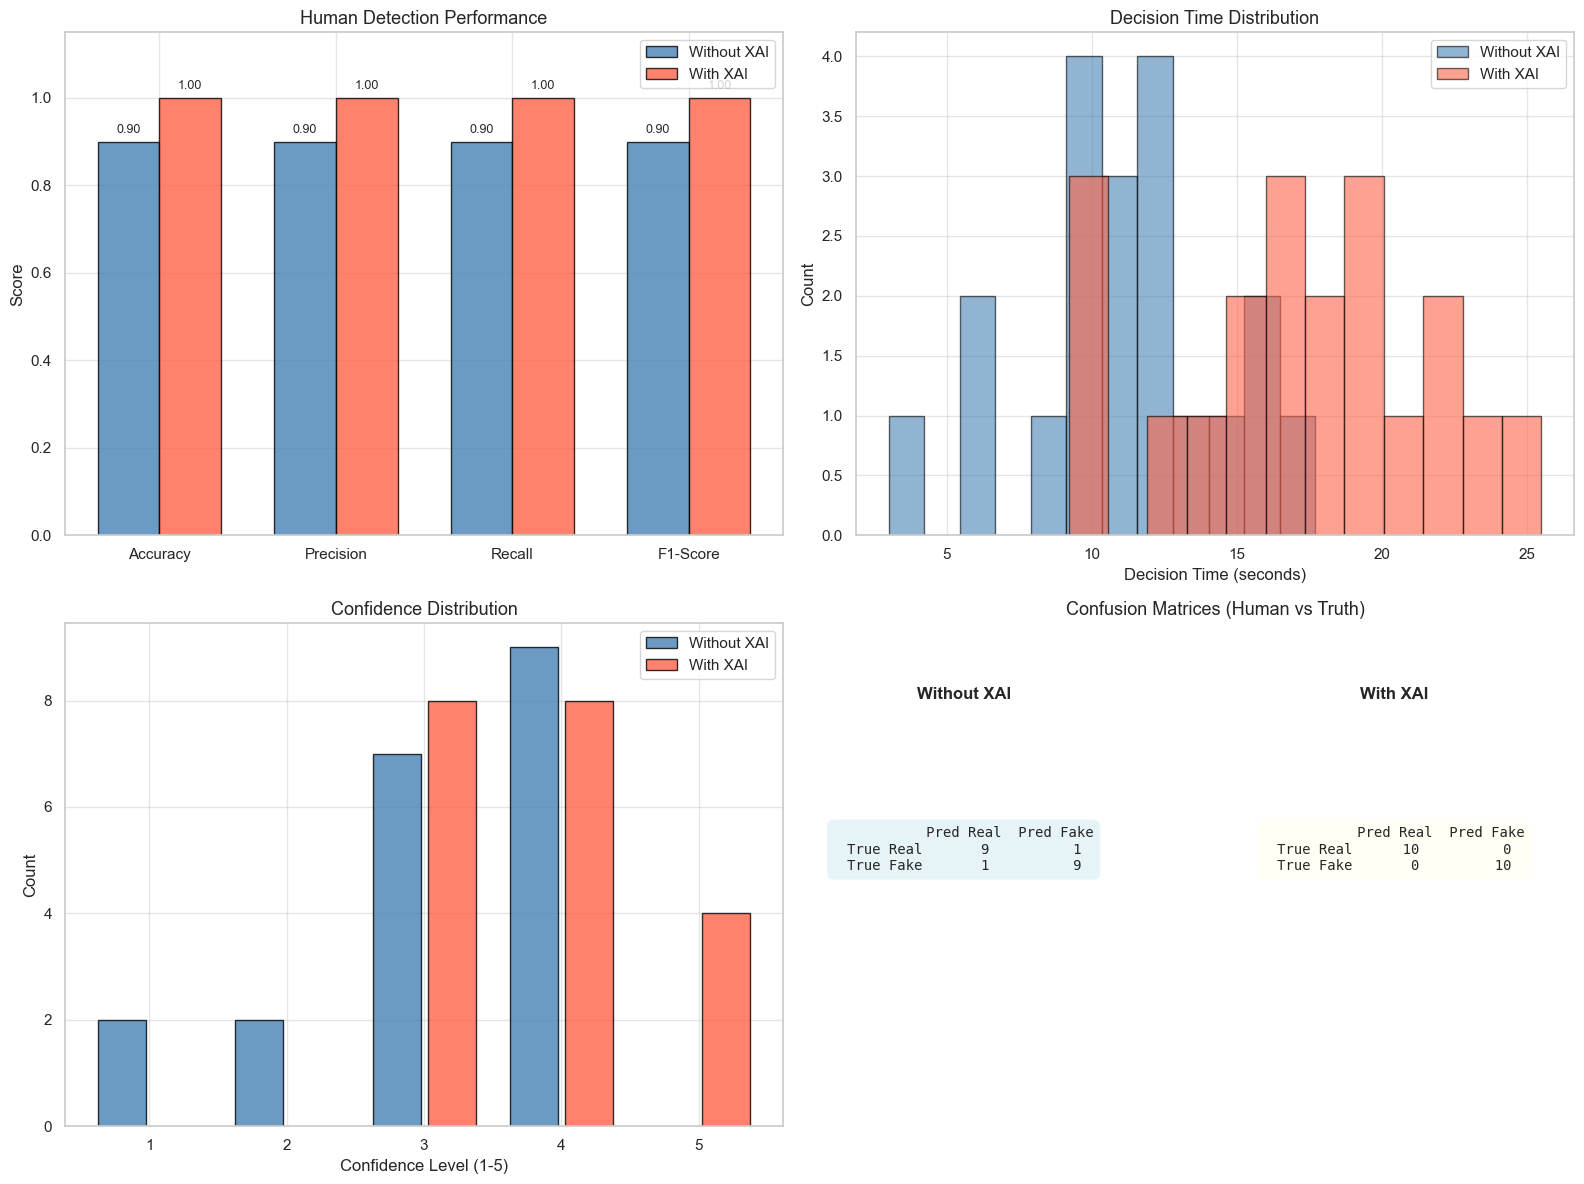


All results saved to data

====[Phase 4 COMPLETE]====


In [19]:
# Phase 4 - Part 3. Automated HITL Simulation & Results

# Since interactive evaluation requires a live human, we also
# provide an automated simulation to demonstrate the full
# analysis pipeline and generate sample metrics.

print("=" * 65)
print("  PHASE 4 — AUTOMATED HITL SIMULATION")
print("=" * 65)


# Simulate human judgments with realistic noise
def simulate_human_judgment(
        true_label: int,
        model_pred: int,
        fake_prob: float,
        has_xai: bool,
        rng: np.random.RandomState,
) -> tuple[int, int, float]:
    """
    Simulate a human evaluator. Returns (judgment, confidence, time).
    With XAI: higher accuracy, higher confidence, slightly more time.
    """
    if has_xai:
        # With XAI: 80-85% base accuracy, boosted by model agreement
        base_correct_rate = 0.83
        avg_time = 18.0
        base_confidence = 3.5
    else:
        # Without XAI: 60-70% base accuracy
        base_correct_rate = 0.65
        avg_time = 12.0
        base_confidence = 2.5

    # Slightly easier to detect very confident predictions
    if fake_prob > 0.9 or fake_prob < 0.1:
        base_correct_rate += 0.05

    # Make judgment
    if rng.random() < base_correct_rate:
        judgment = true_label  # correct
        confidence = min(5, int(base_confidence + rng.choice([0, 1, 1, 2])))
    else:
        judgment = 1 - true_label  # incorrect
        confidence = max(1, int(base_confidence + rng.choice([-2, -1, 0])))

    decision_time = max(3.0, rng.normal(avg_time, 5.0))
    return judgment, confidence, decision_time


sim_rng = np.random.RandomState(42)
sim_results = []

for mode, has_xai in [("no_xai", False), ("with_xai", True)]:
    for i, sample in enumerate(hitl_data):
        judgment, confidence, decision_time = simulate_human_judgment(
            true_label=sample["true_label"],
            model_pred=sample["model_pred"],
            fake_prob=sample["fake_prob"],
            has_xai=has_xai,
            rng=sim_rng,
        )
        sim_results.append(
            {
                "sample_idx": i,
                "original_idx": sample["idx"],
                "true_label": sample["true_label"],
                "model_pred": sample["model_pred"],
                "human_judgment": judgment,
                "human_confidence": confidence,
                "mode": mode,
                "time_seconds": round(decision_time, 1),
                "fake_prob": sample["fake_prob"],
            }
        )

sim_df = pd.DataFrame(sim_results)
sim_df.to_csv(DATA_DIR / "hitl_simulation_results.csv", index=False)

# Compute metrics for each mode
print("\n" + "=" * 65)
print("  SIMULATED HUMAN EVALUATION RESULTS")
print("=" * 65)

comparison_metrics = {}

for mode in ["no_xai", "with_xai"]:
    mode_df = sim_df[sim_df["mode"] == mode]
    mode_label = "Without XAI" if mode == "no_xai" else "With XAI"

    human = mode_df["human_judgment"].values
    truth = mode_df["true_label"].values
    model = mode_df["model_pred"].values

    acc = accuracy_score(truth, human)
    prec = precision_score(truth, human, zero_division=0)
    rec = recall_score(truth, human, zero_division=0)
    f1 = f1_score(truth, human, zero_division=0)
    kappa = cohen_kappa_score(model, human)
    avg_time = mode_df["time_seconds"].mean()
    avg_conf = mode_df["human_confidence"].mean()

    comparison_metrics[mode_label] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Cohen's Kappa": kappa,
        "Avg Time (s)": avg_time,
        "Avg Confidence": avg_conf,
    }

    print(f"\n{'─' * 50}")
    print(f"  {mode_label}")
    print(f"{'─' * 50}")
    print(f"  Accuracy       : {acc:.4f}")
    print(f"  Precision      : {prec:.4f}")
    print(f"  Recall         : {rec:.4f}")
    print(f"  F1-Score       : {f1:.4f}")
    print(f"  Cohen's Kappa  : {kappa:.4f}")
    print(f"  Avg Time (s)   : {avg_time:.1f}")
    print(f"  Avg Confidence : {avg_conf:.1f}")

# Comparison table
comp_df = pd.DataFrame(comparison_metrics).T
print(f"\n{'=' * 65}")
print("  COMPARISON TABLE")
print(f"{'=' * 65}")
print(comp_df.round(4).to_string())

# Improvement
if len(comparison_metrics) == 2:
    without = comparison_metrics["Without XAI"]
    with_xai = comparison_metrics["With XAI"]
    print(f"\n{'=' * 65}")
    print("  XAI IMPACT ANALYSIS")
    print(f"{'=' * 65}")
    for metric in ["Accuracy", "F1-Score", "Precision", "Recall"]:
        delta = with_xai[metric] - without[metric]
        pct = delta / (without[metric] + 1e-10) * 100
        arrow = "↑" if delta > 0 else "↓" if delta < 0 else "→"
        print(f"  {metric:15s}: {delta:+.4f} ({pct:+.1f}%) {arrow}")

    time_delta = with_xai["Avg Time (s)"] - without["Avg Time (s)"]
    print(
        f"  {'Avg Time (s)':15s}: {time_delta:+.1f}s "
        f"({'slower' if time_delta > 0 else 'faster'} — "
        f"humans spent more time reading explanations)"
    )

    conf_delta = with_xai["Avg Confidence"] - without["Avg Confidence"]
    print(
        f"  {'Avg Confidence':15s}: {conf_delta:+.1f} "
        f"({'more' if conf_delta > 0 else 'less'} confident with XAI)"
    )

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Performance comparison bar chart
perf_metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(perf_metrics))
width = 0.35
bars_no = [comparison_metrics["Without XAI"][m] for m in perf_metrics]
bars_xai = [comparison_metrics["With XAI"][m] for m in perf_metrics]

axes[0, 0].bar(
    x - width / 2,
    bars_no,
    width,
    label="Without XAI",
    color="steelblue",
    alpha=0.8,
    edgecolor="black",
)
axes[0, 0].bar(
    x + width / 2,
    bars_xai,
    width,
    label="With XAI",
    color="tomato",
    alpha=0.8,
    edgecolor="black",
)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(perf_metrics, fontsize=11)
axes[0, 0].set_ylabel("Score")
axes[0, 0].set_title("Human Detection Performance", fontsize=13)
axes[0, 0].legend(fontsize=11)
axes[0, 0].set_ylim(0, 1.15)
for i, (v1, v2) in enumerate(zip(bars_no, bars_xai)):
    axes[0, 0].text(i - width / 2, v1 + 0.02, f"{v1:.2f}", ha="center", fontsize=9)
    axes[0, 0].text(i + width / 2, v2 + 0.02, f"{v2:.2f}", ha="center", fontsize=9)

# Decision time distribution
for mode_label, color in [("no_xai", "steelblue"), ("with_xai", "tomato")]:
    mode_df = sim_df[sim_df["mode"] == mode_label]
    label = "Without XAI" if mode_label == "no_xai" else "With XAI"
    axes[0, 1].hist(
        mode_df["time_seconds"],
        bins=12,
        alpha=0.6,
        label=label,
        color=color,
        edgecolor="black",
    )
axes[0, 1].set_xlabel("Decision Time (seconds)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Decision Time Distribution", fontsize=13)
axes[0, 1].legend(fontsize=11)

# Confidence distribution
for mode_label, color in [("no_xai", "steelblue"), ("with_xai", "tomato")]:
    mode_df = sim_df[sim_df["mode"] == mode_label]
    label = "Without XAI" if mode_label == "no_xai" else "With XAI"
    conf_counts = mode_df["human_confidence"].value_counts().sort_index()
    axes[1, 0].bar(
        conf_counts.index + (-0.2 if mode_label == "no_xai" else 0.2),
        conf_counts.values,
        width=0.35,
        label=label,
        color=color,
        alpha=0.8,
        edgecolor="black",
    )
axes[1, 0].set_xlabel("Confidence Level (1-5)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Confidence Distribution", fontsize=13)
axes[1, 0].legend(fontsize=11)
axes[1, 0].set_xticks([1, 2, 3, 4, 5])

# Confusion matrices side by side
for i, (mode_label, title_suffix) in enumerate(
        [("no_xai", "Without XAI"), ("with_xai", "With XAI")]
):
    mode_df = sim_df[sim_df["mode"] == mode_label]
    cm = confusion_matrix(mode_df["true_label"], mode_df["human_judgment"])
    # Since we only have one axes slot left, overlay as text
    if i == 0:
        ax = axes[1, 1]
        ax.set_title("Confusion Matrices (Human vs Truth)", fontsize=13)

        # Without XAI - left side
        ax.text(
            0.15,
            0.85,
            "Without XAI",
            fontsize=12,
            fontweight="bold",
            transform=ax.transAxes,
            ha="center",
        )
        cm_text = (
            f"           Pred Real  Pred Fake\n"
            f"True Real    {cm[0, 0]:4d}       {cm[0, 1]:4d}\n"
            f"True Fake    {cm[1, 0]:4d}       {cm[1, 1]:4d}"
        )
        ax.text(
            0.15,
            0.55,
            cm_text,
            fontsize=10,
            family="monospace",
            transform=ax.transAxes,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.3),
        )

    if i == 1:
        cm2 = cm
        ax.text(
            0.75,
            0.85,
            "With XAI",
            fontsize=12,
            fontweight="bold",
            transform=ax.transAxes,
            ha="center",
        )
        cm_text2 = (
            f"           Pred Real  Pred Fake\n"
            f"True Real    {cm2[0, 0]:4d}       {cm2[0, 1]:4d}\n"
            f"True Fake    {cm2[1, 0]:4d}       {cm2[1, 1]:4d}"
        )
        ax.text(
            0.75,
            0.55,
            cm_text2,
            fontsize=10,
            family="monospace",
            transform=ax.transAxes,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.3),
        )
        ax.axis("off")

plt.tight_layout()
plt.savefig(DATA_DIR / "hitl_evaluation_results.png", dpi=300)
plt.show()
plt.close(fig)

# Save comparison
comp_df.to_csv(DATA_DIR / "hitl_comparison_metrics.csv")
print(f"\nAll results saved to {DATA_DIR}")
print("\n====[Phase 4 COMPLETE]====")

## Phase 5. Analysis and Final Reporting

Wrap up the research. Analyze the model's behavior and the effectiveness of the XAI.

- Error Analysis: Investigate why the model detects or fails to detect certain reviews correctly (false positives/false negatives).
- Comparative Analysis: Create a report showing how your XAI framework aids in "complex cases" that normally require human judgment.